## 20251027 Numerical Bathtub

## 1. Model build-up

Let's consider solving the time-dependent regulator model numerically. We start with writing down the set of ODEs and note that I replace all the parameters into surface density to describe the spatially-resolved scenario.

First, as usual, we define the SFR surface density in two ways: 
$$
\begin{split}
\Sigma_\mathrm{SFR}[t] = \epsilon[t]\Sigma_\mathrm{g}[t] = \frac{d}{dt}\Sigma_*[t]
\end{split}
$$
Then, the change of gas mass surface density:
$$
\begin{split}
\frac{d}{dt}\Sigma_\mathrm{g}[t] = \Sigma_\mathrm{in}[t]-(1-R+\lambda)\epsilon[t]\Sigma_\mathrm{g}[t]
\end{split}
$$
Next, the change of metal mass surface density:
$$
\begin{split}
\frac{d}{dt}\Sigma_Z[t] = y(1-R)\epsilon[t]\Sigma_\mathrm{g}[t]-(1-R+\lambda)\epsilon[t]\Sigma_\mathrm{g}[t]Z[t]+\Sigma_\mathrm{in}[t]Z_\mathrm{in}
\end{split}
$$
And, we also define the metallicity as:
$$
\begin{split}
Z[t]=\frac{\Sigma_Z[t]}{\Sigma_\mathrm{g}[t]}
\end{split}
$$
Also, the sSFR:
$$
\begin{split}
\mathrm{sSFR} = \frac{\Sigma_\mathrm{SFR}}{\Sigma_*}
\end{split}
$$
Finally, we can convert metallicity to observable with solar abundace at 8.69 (Asplund+2021):
$$
\begin{split}
12+\log_{10}(\mathrm{O/H})[t] = 8.69+\log_{10}(Z[t])
\end{split}
$$

## 2. Constants and initial values

Here, return fraction, metal yield per stellar, mass loading factor and inflow metallicity are constants:
$$
\left\{
\begin{split}
R &= 0.5 \\
y &= 0.01 \\
\lambda &= 1.5 \\
Z_\mathrm{in} &= 0.1 \\
\end{split}
\right.
$$
Now let's say at $t=0\mathrm{Myr}$,  we have 
$$
\left\{
\begin{split}
\epsilon_0 &= \epsilon[t=0] = \frac{\Sigma_\mathrm{SFR,0}}{\Sigma_\mathrm{g,0}} = 10^{-9}/\mathrm{yr} \\
\Sigma_\mathrm{in,0} &= \Sigma_\mathrm{in}[t=0] = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
Z_0 &= Z[t=0] = 0.5 \\
\Sigma_{*,0} &= \Sigma_*[t=0] = 10^7\mathrm{M_\odot/kpc^2} \\
\Sigma_\mathrm{g,0} &= \Sigma_\mathrm{g}[t=0] = 10^6\mathrm{M_\odot/kpc^2} \\
\Sigma_\mathrm{SFR,0} &= \Sigma_\mathrm{SFR}[t=0] = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
\mathrm{sSFR}_0 &= \mathrm{sSFR}[t=0] = \frac{\Sigma_\mathrm{SFR,0}}{\Sigma_{*,0}} = 10^{-10}/\mathrm{yr} \\
\Sigma_{Z,0} &= \Sigma_{Z}[t=0] = \Sigma_\mathrm{in,0}\Sigma_{Z,0} = 0.5\times10^6\mathrm{M_\odot/kpc^2} \\
12+\log_{10}(\mathrm{O/H})_0 &= 12+\log_{10}(\mathrm{O/H})[t=0] = 8.69+\log_{10}(Z_0) \\
\end{split}
\right.
$$

## 3. Numerical forms of $\epsilon[t]$ and $\Sigma_\mathrm{in}[t]$

We consider the following cases:

### 3.1 Constant $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

A simple case that both are constant:
$$
\left\{
\begin{split}
\epsilon[t] &= \epsilon_0 = 10^{-9}/\mathrm{yr} \\
\Sigma_\mathrm{in}[t] &= \Sigma_\mathrm{in,0} = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
\end{split}
\right.
$$

### 3.2 Sinusoidal variation of $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

Here we define a constant $A=0.1$ here to denote the amplitide of the sinusoidal variation compared to initial value, and $T_p = 1000$ (in the unit of Myr) to indicate the variation period:
$$
\left\{
\begin{split}
\epsilon[t] &= \epsilon_0 + A\epsilon_0\sin(\frac{2\pi t}{T_p}) \\
\Sigma_\mathrm{in}[t] &= \Sigma_\mathrm{in,0} = 10^{-3}\mathrm{M_\odot/yr/kpc^2} \\
\end{split}
\right.
$$

### 3.3 Constant $\epsilon[t]$ and sinusoidal variation of $\Sigma_\mathrm{in}[t]$

Similarly, we have:
$$
\left\{
\begin{split}
\epsilon[t] &= \epsilon_0 = 10^{-9}/\mathrm{yr} \\
\Sigma_\mathrm{in}[t] &= \Sigma_\mathrm{in,0} + A\Sigma_\mathrm{in,0}\sin(\frac{2\pi t}{T_p}) \\
\end{split}
\right.
$$

## 4. Evolution

We consider a total period of $T = 10\mathrm{Gyr}$, with a timestep of $\Delta t = 0.1\mathrm{Myr}$. Thus, for any given moment $t_i \in [0,T]$, the iteration in the next timestamp ($t_{i+1} = t_i+\Delta t$) will be 
$$
\left\{
\begin{split}
\epsilon[t_{i+1}] &= \epsilon[t_{i+1}] \\
\Sigma_\mathrm{in}[t_{i+1}] &= \Sigma_\mathrm{in}[t_{i+1}] \\
\Sigma_\mathrm{g}[t_{i+1}] &= \Sigma_\mathrm{g}[t_i]+\frac{d}{dt}\Sigma_\mathrm{g}[t_i]\Delta t \\ 
&= \Sigma_\mathrm{g}[t_i]+(\Sigma_\mathrm{in}[t_i]-(1-R+\lambda)\epsilon[t_i]\Sigma_\mathrm{g}[t_i])\Delta t \\
\Sigma_Z[t_{i+1}] &= \Sigma_\mathrm{Z}[t_i]+\frac{d}{dt}\Sigma_\mathrm{Z}[t_i]\Delta t \\ 
&= \Sigma_\mathrm{Z}[t_i]+(y(1-R)\epsilon[t_i]\Sigma_\mathrm{g}[t_i]-(1-R+\lambda)\epsilon[t_i]\Sigma_\mathrm{g}[t_i]Z[t_i]+\Sigma_\mathrm{in}[t_i]Z_\mathrm{in})\Delta t \\ 
\Sigma_\mathrm{SFR}[t_{i+1}] &= \epsilon[t_{i+1}]\Sigma_\mathrm{g}[t_{i+1}] \\
Z[t_{i+1}] &= \frac{\Sigma_Z[t_{i+1}]}{\Sigma_\mathrm{g}[t_{i+1}]} \\
\Sigma_*[t_{i+1}] &= \Sigma_*[t_{i}]+\Sigma_\mathrm{SFR}[t_i]\Delta t \\
\mathrm{sSFR}[t_{i+1}] &= \frac{\Sigma_\mathrm{SFR}[t_{i+1}]}{\Sigma_*[t_{i+1}]} \\
12+\log_{10}(\mathrm{O/H})[t_{i+1}] &= 8.69+\log_{10}(Z[t_{i+1}]) \\
\end{split}
\right.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Global parameters
T = 10000e6  # yr (total evolution time)
dt = 0.1e6   # yr (timestep)

In [3]:
## Local parameters
R = 0.5          # Return fraction
y = 0.1         # Metal yield per stellar generation
lmbda = 1.5      # Mass loading factor (using lmbda instead of lambda to avoid keyword)
Z_in = 0.3       # Z_sol (inflow metallicity)

In [4]:
## Sinusoidal variation parameters
A = 0.1       # Amplitude of sinusoidal variation for epsilon (fraction of initial value)
B = 0.01       # Amplitude of sinusoidal variation for inflow rate (fraction of initial value)
T_p = 2000e6  # yr (period of sinusoidal variation)

In [5]:
## Initial values at t=0
epsilon_0 = 1e-8            # 1/yr (star formation efficiency)
Sigma_in_0 = 1e-3           # M_sol/yr/kpc^2 (inflow rate surface density)
Sigma_star_0 = 1e7          # M_sol/kpc^2 (stellar surface density)
Sigma_g_0 = Sigma_in_0/((1-R+lmbda)*epsilon_0)           # M_sol/kpc^2 (gas surface density)
Sigma_SFR_0 = epsilon_0 * Sigma_g_0          # M_sol/yr/kpc^2 (SFR surface density)
sSFR_0 = Sigma_SFR_0 / Sigma_star_0  # 1/yr (specific SFR)
Z_0 = Z_in + y*(1-R) * Sigma_SFR_0 / Sigma_in_0                    # Z_sol (initial metallicity)
Sigma_Z_0 = Z_0 * Sigma_g_0          # M_sol/kpc^2 (metal surface density)
OH_0 = 8.69 + np.log10(Z_0)  # 12 + log10(O/H) (oxygen abundance)

# Additional derived quantities
log10_Sigma_SFR_0 = np.log10(Sigma_SFR_0)  # log10(M_sol/yr/kpc^2)
log10_Sigma_star_0 = np.log10(Sigma_star_0)  # log10(M_sol/kpc^2)
log10_sSFR_0 = np.log10(sSFR_0)  # log10(1/yr)

print(f"Star formation efficiency at t=0: {epsilon_0} 1/yr ")
print(f"Inflow rate surface density at t=0: {Sigma_in_0} M_sol/yr/kpc^2 ")
print(f"Initial metallicity at t=0: {Z_0} Z_sol ")
print(f"Stellar surface density at t=0: {Sigma_star_0} M_sol/kpc^2 ")
print(f"Gas surface density at t=0: {Sigma_g_0} M_sol/kpc^2 ")
print(f"SFR surface density at t=0: {Sigma_SFR_0} M_sol/yr/kpc^2 ")
print(f"Specific SFR at t=0: {sSFR_0} 1/yr ")
print(f"Metal surface density at t=0: {Sigma_Z_0} M_sol/kpc^2 ")
print(f"Metallicity at t=0: {Z_0} Z_sol")
print(f"Oxygen abundance at t=0: {OH_0} ")
print(f"log10(Sigma_SFR) at t=0: {log10_Sigma_SFR_0} ")
print(f"log10(Sigma_star) at t=0: {log10_Sigma_star_0} ")
print(f"log10(sSFR) at t=0: {log10_sSFR_0} ")


Star formation efficiency at t=0: 1e-08 1/yr 
Inflow rate surface density at t=0: 0.001 M_sol/yr/kpc^2 
Initial metallicity at t=0: 0.325 Z_sol 
Stellar surface density at t=0: 10000000.0 M_sol/kpc^2 
Gas surface density at t=0: 50000.0 M_sol/kpc^2 
SFR surface density at t=0: 0.0005 M_sol/yr/kpc^2 
Specific SFR at t=0: 5e-11 1/yr 
Metal surface density at t=0: 16250.0 M_sol/kpc^2 
Metallicity at t=0: 0.325 Z_sol
Oxygen abundance at t=0: 8.201883360978874 
log10(Sigma_SFR) at t=0: -3.3010299956639813 
log10(Sigma_star) at t=0: 7.0 
log10(sSFR) at t=0: -10.301029995663981 


In [6]:
## Define evolution function
def run_evolution(epsilon_type='const', Sigma_in_type='const'):
    """
    Run the time evolution for given epsilon and Sigma_in types.
    
    Parameters:
    -----------
    epsilon_type : str
        'const' for constant epsilon, 'sin' for sinusoidal variation, 'exp' for exponential decay
    Sigma_in_type : str
        'const' for constant Sigma_in, 'sin' for sinusoidal variation, 'exp' for exponential decay
    
    Returns:
    --------
    dict : Dictionary containing all evolution arrays with appropriate names
    """
    
    # Number of timesteps
    n_steps = int(T / dt)
    
    # Calculate k for exponential decay case if needed
    if epsilon_type == 'exp':
        # k = epsilon_0 * (1 - R + lmbda - Sigma_in_0 / (epsilon_0 * Sigma_g_0))
        k = epsilon_0 * (1 - R + lmbda)*1e-2
        print(f"  Exponential decay parameter k_epsilon = {k:.6e} yr^-1")
    
    if Sigma_in_type == 'exp':
        # k for Sigma_in decay (flip case of epsilon)
        k_Sigma_in = epsilon_0 * (1 - R + lmbda)
        print(f"  Exponential decay parameter k_Sigma_in = {k_Sigma_in:.6e} yr^-1")
    
    # Initialize arrays to store evolution
    t_array = np.zeros(n_steps + 1)
    epsilon_array = np.zeros(n_steps + 1)
    Sigma_in_array = np.zeros(n_steps + 1)
    Sigma_g_array = np.zeros(n_steps + 1)
    Sigma_Z_array = np.zeros(n_steps + 1)
    Sigma_SFR_array = np.zeros(n_steps + 1)
    Z_array = np.zeros(n_steps + 1)
    Sigma_star_array = np.zeros(n_steps + 1)
    sSFR_array = np.zeros(n_steps + 1)
    OH_array = np.zeros(n_steps + 1)
    log10_Sigma_SFR_array = np.zeros(n_steps + 1)
    log10_Sigma_star_array = np.zeros(n_steps + 1)
    log10_sSFR_array = np.zeros(n_steps + 1)
    
    # Set initial conditions (i=0)
    t_array[0] = 0
    epsilon_array[0] = epsilon_0
    Sigma_in_array[0] = Sigma_in_0
    Sigma_g_array[0] = Sigma_g_0
    Sigma_Z_array[0] = Sigma_Z_0
    Sigma_SFR_array[0] = Sigma_SFR_0
    Z_array[0] = Z_0
    Sigma_star_array[0] = Sigma_star_0
    sSFR_array[0] = sSFR_0
    OH_array[0] = OH_0
    log10_Sigma_SFR_array[0] = log10_Sigma_SFR_0
    log10_Sigma_star_array[0] = log10_Sigma_star_0
    log10_sSFR_array[0] = log10_sSFR_0
    
    # Time evolution loop
    for i in range(n_steps):
        # Current time
        t_i = t_array[i]
        
        # Update time for next step FIRST (needed for sin calculations)
        t_array[i+1] = t_i + dt
        
        # Update epsilon[t_{i+1}] based on type
        if epsilon_type == 'const':
            # Case 4.1 or 4.3: epsilon[t] = epsilon_0
            epsilon_array[i+1] = epsilon_0
        elif epsilon_type == 'sin':
            # Case 4.2: epsilon[t] = epsilon_0 * (1 + A*sin(2*pi*t/T_p))
            epsilon_array[i+1] = epsilon_0 * (1 + A * np.sin(2 * np.pi * t_array[i+1] / T_p))
        elif epsilon_type == 'exp':
            # Case 5: epsilon[t] = epsilon_0 * exp(-k*t)
            epsilon_array[i+1] = epsilon_0 * np.exp(-k * t_array[i+1])
        
        # Update Sigma_in[t_{i+1}] based on type
        if Sigma_in_type == 'const':
            # Case 4.1 or 4.2: Sigma_in[t] = Sigma_in_0
            Sigma_in_array[i+1] = Sigma_in_0
        elif Sigma_in_type == 'sin':
            # Case 4.3: Sigma_in[t] = Sigma_in_0 * (1 + B*sin(2*pi*t/T_p))
            Sigma_in_array[i+1] = Sigma_in_0 * (1 + B * np.sin(2 * np.pi * t_array[i+1] / T_p))
        elif Sigma_in_type == 'exp':
            # Case 6: Sigma_in[t] = Sigma_in_0 * exp(-k_Sigma_in*t)
            Sigma_in_array[i+1] = Sigma_in_0 * np.exp(-k_Sigma_in * t_array[i+1])
        
        # Update gas surface density
        # Sigma_g[t_{i+1}] = Sigma_g[t_i] + (Sigma_in[t_i] - (1-R+lambda)*epsilon[t_i]*Sigma_g[t_i]) * dt
        dSigma_g_dt = Sigma_in_array[i] - (1 - R + lmbda) * epsilon_array[i] * Sigma_g_array[i]
        Sigma_g_array[i+1] = Sigma_g_array[i] + dSigma_g_dt * dt
        
        # Update metal surface density
        # Sigma_Z[t_{i+1}] = Sigma_Z[t_i] + (y*(1-R)*epsilon[t_i]*Sigma_g[t_i] - (1-R+lambda)*epsilon[t_i]*Sigma_g[t_i]*Z[t_i] + Sigma_in[t_i]*Z_in) * dt
        dSigma_Z_dt = (y * (1 - R) * epsilon_array[i] * Sigma_g_array[i] 
                       - (1 - R + lmbda) * epsilon_array[i] * Sigma_g_array[i] * Z_array[i] 
                       + Sigma_in_array[i] * Z_in)
        Sigma_Z_array[i+1] = Sigma_Z_array[i] + dSigma_Z_dt * dt
        
        # Update SFR surface density
        # Sigma_SFR[t_{i+1}] = epsilon[t_{i+1}] * Sigma_g[t_{i+1}]
        Sigma_SFR_array[i+1] = epsilon_array[i+1] * Sigma_g_array[i+1]
        
        # Update metallicity
        # Z[t_{i+1}] = Sigma_Z[t_{i+1}] / Sigma_g[t_{i+1}]
        Z_array[i+1] = Sigma_Z_array[i+1] / Sigma_g_array[i+1]
        
        # Update stellar surface density
        # Sigma_*[t_{i+1}] = Sigma_*[t_i] + Sigma_SFR[t_i] * dt
        Sigma_star_array[i+1] = Sigma_star_array[i] + Sigma_SFR_array[i] * dt
        
        # Update sSFR
        # sSFR[t_{i+1}] = Sigma_SFR[t_{i+1}] / Sigma_*[t_{i+1}]
        sSFR_array[i+1] = Sigma_SFR_array[i+1] / Sigma_star_array[i+1]
        
        # Update oxygen abundance
        # 12 + log10(O/H)[t_{i+1}] = 8.69 + log10(Z[t_{i+1}])
        OH_array[i+1] = 8.69 + np.log10(Z_array[i+1])
        
        # Update additional derived quantities
        # log10(Sigma_SFR[t_{i+1}])
        log10_Sigma_SFR_array[i+1] = np.log10(Sigma_SFR_array[i+1])
        
        # log10(Sigma_*[t_{i+1}])
        log10_Sigma_star_array[i+1] = np.log10(Sigma_star_array[i+1])
        
        # log10(sSFR[t_{i+1}])
        log10_sSFR_array[i+1] = np.log10(sSFR_array[i+1])
    
    # Create suffix for array names
    suffix = f"{epsilon_type}_epsilon_{Sigma_in_type}_Sigma_in"
    
    # Store results in dictionary with appropriate names
    results = {
        f't_array_{suffix}': t_array,
        f'epsilon_array_{suffix}': epsilon_array,
        f'Sigma_in_array_{suffix}': Sigma_in_array,
        f'Sigma_g_array_{suffix}': Sigma_g_array,
        f'Sigma_Z_array_{suffix}': Sigma_Z_array,
        f'Sigma_SFR_array_{suffix}': Sigma_SFR_array,
        f'Z_array_{suffix}': Z_array,
        f'Sigma_star_array_{suffix}': Sigma_star_array,
        f'sSFR_array_{suffix}': sSFR_array,
        f'OH_array_{suffix}': OH_array,
        f'log10_Sigma_SFR_array_{suffix}': log10_Sigma_SFR_array,
        f'log10_Sigma_star_array_{suffix}': log10_Sigma_star_array,
        f'log10_sSFR_array_{suffix}': log10_sSFR_array
    }
    
    print(f"Evolution complete for epsilon={epsilon_type}, Sigma_in={Sigma_in_type}")
    print(f"  Total timesteps: {n_steps}")
    print(f"  Final time: {t_array[-1]} Myr")
    print(f"  Arrays saved with suffix: {suffix}")
    
    return results

print("Evolution function defined. Ready to run simulations.")


Evolution function defined. Ready to run simulations.


In [7]:
## Run all cases and store results in global namespace

# Case 4.1: Constant epsilon and constant Sigma_in
print("\n=== Case 4.1: Constant epsilon, Constant Sigma_in ===")
results_const_const = run_evolution(epsilon_type='const', Sigma_in_type='const')
# Unpack to global namespace
for key, value in results_const_const.items():
    globals()[key] = value

# Case 4.2: Sinusoidal epsilon and constant Sigma_in  
print("\n=== Case 4.2: Sinusoidal epsilon, Constant Sigma_in ===")
results_sin_const = run_evolution(epsilon_type='sin', Sigma_in_type='const')
# Unpack to global namespace
for key, value in results_sin_const.items():
    globals()[key] = value

# Case 4.3: Constant epsilon and sinusoidal Sigma_in
print("\n=== Case 4.3: Constant epsilon, Sinusoidal Sigma_in ===")
results_const_sin = run_evolution(epsilon_type='const', Sigma_in_type='sin')
# Unpack to global namespace
for key, value in results_const_sin.items():
    globals()[key] = value

# Case 4.4 (bonus): Sinusoidal epsilon and sinusoidal Sigma_in
print("\n=== Case 4.4 (Bonus): Sinusoidal epsilon, Sinusoidal Sigma_in ===")
results_sin_sin = run_evolution(epsilon_type='sin', Sigma_in_type='sin')
# Unpack to global namespace
for key, value in results_sin_sin.items():
    globals()[key] = value

# Case 5: Exponential decay epsilon and constant Sigma_in
print("\n=== Case 5: Exponential decay epsilon, Constant Sigma_in ===")
results_exp_const = run_evolution(epsilon_type='exp', Sigma_in_type='const')
# Unpack to global namespace
for key, value in results_exp_const.items():
    globals()[key] = value

# Case 6: Constant epsilon and exponential decay Sigma_in
print("\n=== Case 6: Constant epsilon, Exponential decay Sigma_in ===")
results_const_exp = run_evolution(epsilon_type='const', Sigma_in_type='exp')
# Unpack to global namespace
for key, value in results_const_exp.items():
    globals()[key] = value

print("\n" + "="*60)
print("All cases complete! Available arrays:")
print("="*60)
print("\nExample array names:")
print("  - OH_array_const_epsilon_const_Sigma_in")
print("  - OH_array_sin_epsilon_const_Sigma_in")
print("  - OH_array_const_epsilon_sin_Sigma_in")
print("  - OH_array_sin_epsilon_sin_Sigma_in")
print("  - OH_array_exp_epsilon_const_Sigma_in")
print("  - OH_array_const_epsilon_exp_Sigma_in")
print("\nAll parameters have corresponding arrays with these suffixes.")



=== Case 4.1: Constant epsilon, Constant Sigma_in ===
Evolution complete for epsilon=const, Sigma_in=const
  Total timesteps: 100000
  Final time: 10000000000.0 Myr
  Arrays saved with suffix: const_epsilon_const_Sigma_in

=== Case 4.2: Sinusoidal epsilon, Constant Sigma_in ===
Evolution complete for epsilon=sin, Sigma_in=const
  Total timesteps: 100000
  Final time: 10000000000.0 Myr
  Arrays saved with suffix: sin_epsilon_const_Sigma_in

=== Case 4.3: Constant epsilon, Sinusoidal Sigma_in ===
Evolution complete for epsilon=const, Sigma_in=sin
  Total timesteps: 100000
  Final time: 10000000000.0 Myr
  Arrays saved with suffix: const_epsilon_sin_Sigma_in

=== Case 4.4 (Bonus): Sinusoidal epsilon, Sinusoidal Sigma_in ===
Evolution complete for epsilon=sin, Sigma_in=sin
  Total timesteps: 100000
  Final time: 10000000000.0 Myr
  Arrays saved with suffix: sin_epsilon_sin_Sigma_in

=== Case 5: Exponential decay epsilon, Constant Sigma_in ===
  Exponential decay parameter k_epsilon = 2.00

## 20251028 Case 1: constant $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

In [8]:
# ## Visualization of all 12 parameters evolution for Case that constant epsilon and constant Sigma_in

# # Create figure with 12 subplots (6 rows x 2 columns)
# fig, axes = plt.subplots(6, 2, figsize=(16, 20))
# axes = axes.flatten()

# # Use the const_epsilon_const_Sigma_in arrays
# t = t_array_const_epsilon_const_Sigma_in
# epsilon = epsilon_array_const_epsilon_const_Sigma_in
# Sigma_in = Sigma_in_array_const_epsilon_const_Sigma_in
# Sigma_g = Sigma_g_array_const_epsilon_const_Sigma_in
# Sigma_Z = Sigma_Z_array_const_epsilon_const_Sigma_in
# Sigma_SFR = Sigma_SFR_array_const_epsilon_const_Sigma_in
# Z = Z_array_const_epsilon_const_Sigma_in
# Sigma_star = Sigma_star_array_const_epsilon_const_Sigma_in
# sSFR = sSFR_array_const_epsilon_const_Sigma_in
# OH = OH_array_const_epsilon_const_Sigma_in
# log10_Sigma_SFR = log10_Sigma_SFR_array_const_epsilon_const_Sigma_in
# log10_Sigma_star = log10_Sigma_star_array_const_epsilon_const_Sigma_in
# log10_sSFR = log10_sSFR_array_const_epsilon_const_Sigma_in

# # 1. epsilon[t]
# axes[0].plot(t, epsilon, 'b-', linewidth=1.5)
# axes[0].set_xlabel('Time [yr]')
# axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
# axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$')
# axes[0].grid(True, alpha=0.3)

# # 2. Sigma_in[t]
# axes[1].plot(t, Sigma_in, 'g-', linewidth=1.5)
# axes[1].set_xlabel('Time [yr]')
# axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
# axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$')
# axes[1].grid(True, alpha=0.3)

# # 3. Sigma_g[t]
# axes[2].plot(t, Sigma_g, 'purple', linewidth=1.5)
# axes[2].set_xlabel('Time [yr]')
# axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
# axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
# axes[2].grid(True, alpha=0.3)

# # 4. Sigma_Z[t]
# axes[3].plot(t, Sigma_Z, 'brown', linewidth=1.5)
# axes[3].set_xlabel('Time [yr]')
# axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
# axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
# axes[3].grid(True, alpha=0.3)

# # 5. Sigma_SFR[t]
# axes[4].plot(t, Sigma_SFR, 'red', linewidth=1.5)
# axes[4].set_xlabel('Time [yr]')
# axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
# axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
# axes[4].grid(True, alpha=0.3)

# # 6. Z[t]
# axes[5].plot(t, Z, 'orange', linewidth=1.5)
# axes[5].set_xlabel('Time [yr]')
# axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
# axes[5].set_title(r'Metallicity $Z(t)$')
# axes[5].grid(True, alpha=0.3)

# # 7. Sigma_star[t]
# axes[6].plot(t, Sigma_star, 'navy', linewidth=1.5)
# axes[6].set_xlabel('Time [yr]')
# axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
# axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
# axes[6].grid(True, alpha=0.3)

# # 8. sSFR[t]
# axes[7].plot(t, sSFR, 'magenta', linewidth=1.5)
# axes[7].set_xlabel('Time [yr]')
# axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
# axes[7].set_title(r'Specific SFR sSFR$(t)$')
# axes[7].grid(True, alpha=0.3)

# # 9. 12 + log10(O/H)[t]
# axes[8].plot(t, OH, 'cyan', linewidth=1.5)
# axes[8].set_xlabel('Time [yr]')
# axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
# axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
# axes[8].grid(True, alpha=0.3)

# # 10. log10(Sigma_SFR)[t]
# axes[9].plot(t, log10_Sigma_SFR, 'darkred', linewidth=1.5)
# axes[9].set_xlabel('Time [yr]')
# axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
# axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
# axes[9].grid(True, alpha=0.3)

# # 11. log10(Sigma_star)[t]
# axes[10].plot(t, log10_Sigma_star, 'darkblue', linewidth=1.5)
# axes[10].set_xlabel('Time [yr]')
# axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
# axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
# axes[10].grid(True, alpha=0.3)

# # 12. log10(sSFR)[t]
# axes[11].plot(t, log10_sSFR, 'darkmagenta', linewidth=1.5)
# axes[11].set_xlabel('Time [yr]')
# axes[11].set_ylabel(r'log$_{10}$(sSFR)')
# axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
# axes[11].grid(True, alpha=0.3)

# # Add overall title
# fig.suptitle('Constant $\\epsilon(t)$ and Constant $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
#              fontsize=16, fontweight='bold', y=0.995)

# plt.tight_layout(rect=[0, 0, 1, 0.995])
# plt.show()

# print(f"\nSummary of Case 4.1 evolution:")
# print(f"  Initial Z = {Z[0]:.6f} Z_sol")
# print(f"  Final Z = {Z[-1]:.6f} Z_sol")


## 20251028 Case 2: sinusoidal variation of $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

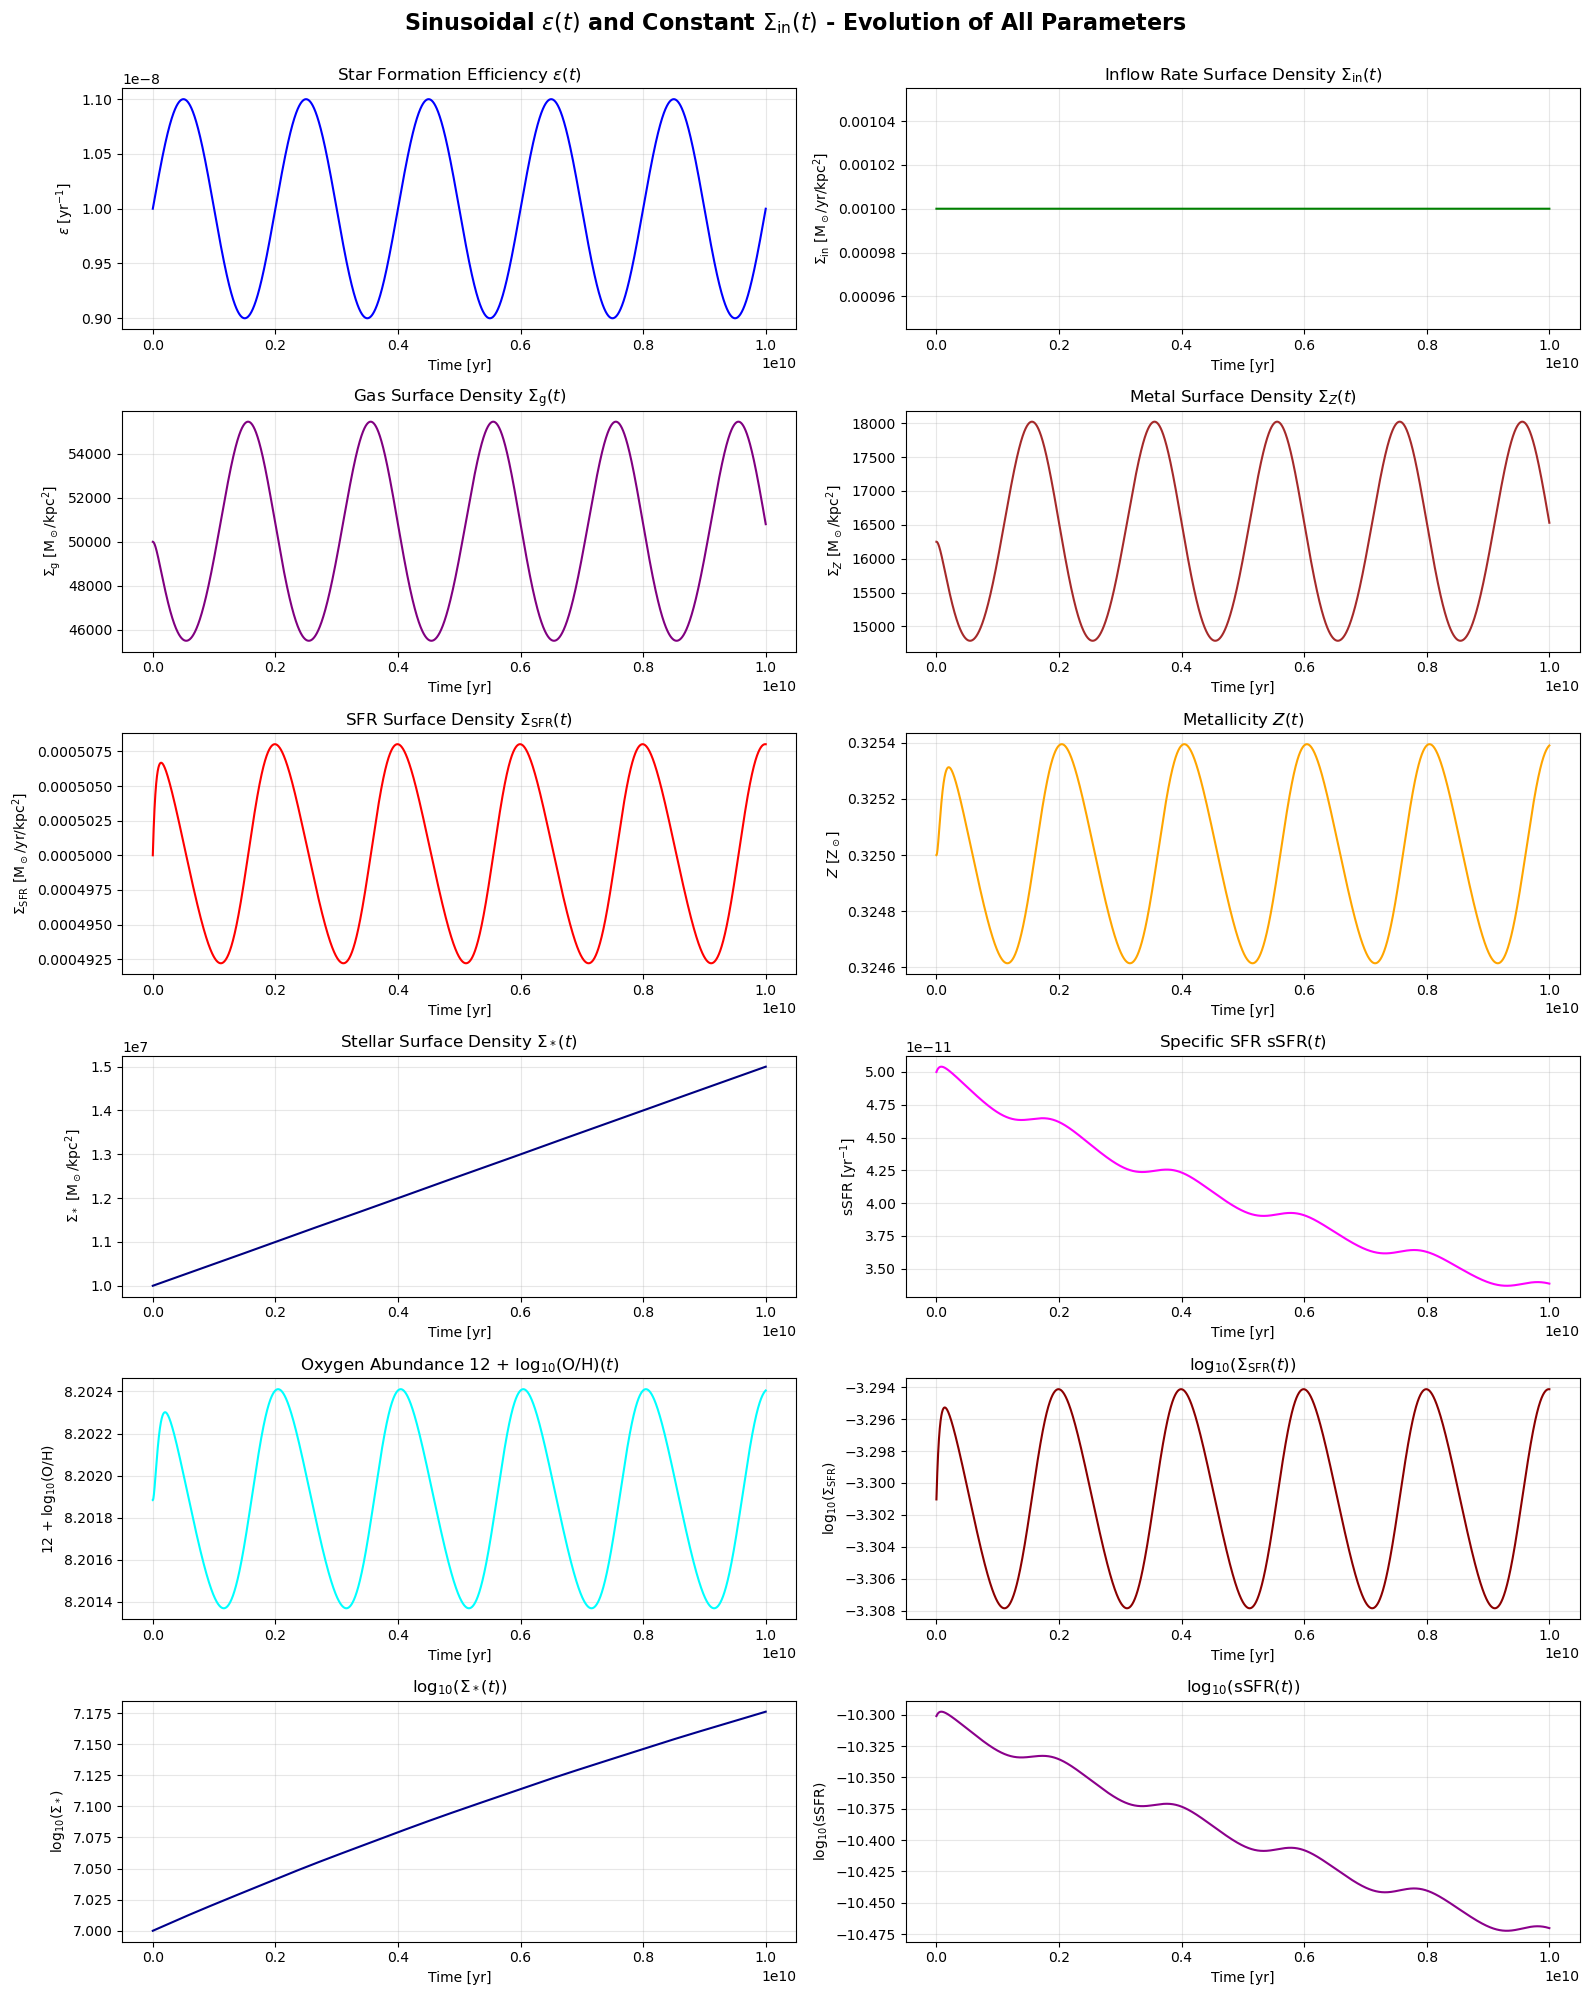


Summary of Case 4.2 evolution:
  Initial Z = 0.325000 Z_sol
  Final Z = 0.325390 Z_sol


In [9]:
## Visualization of all 12 parameters evolution for Case that sinusoidal epsilon and constant Sigma_in

# Create figure with 12 subplots (6 rows x 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
axes = axes.flatten()

# 1. epsilon[t]
axes[0].plot(t_array_sin_epsilon_const_Sigma_in, epsilon_array_sin_epsilon_const_Sigma_in, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t_array_sin_epsilon_const_Sigma_in, Sigma_in_array_sin_epsilon_const_Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t_array_sin_epsilon_const_Sigma_in, Sigma_g_array_sin_epsilon_const_Sigma_in, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t_array_sin_epsilon_const_Sigma_in, Sigma_Z_array_sin_epsilon_const_Sigma_in, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t_array_sin_epsilon_const_Sigma_in, Sigma_SFR_array_sin_epsilon_const_Sigma_in, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t_array_sin_epsilon_const_Sigma_in, Z_array_sin_epsilon_const_Sigma_in, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t_array_sin_epsilon_const_Sigma_in, Sigma_star_array_sin_epsilon_const_Sigma_in, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t_array_sin_epsilon_const_Sigma_in, sSFR_array_sin_epsilon_const_Sigma_in, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t_array_sin_epsilon_const_Sigma_in, OH_array_sin_epsilon_const_Sigma_in, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t_array_sin_epsilon_const_Sigma_in, log10_Sigma_SFR_array_sin_epsilon_const_Sigma_in, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t_array_sin_epsilon_const_Sigma_in, log10_Sigma_star_array_sin_epsilon_const_Sigma_in, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t_array_sin_epsilon_const_Sigma_in, log10_sSFR_array_sin_epsilon_const_Sigma_in, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Sinusoidal $\\epsilon(t)$ and Constant $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 4.2 evolution:")
print(f"  Initial Z = {Z_array_sin_epsilon_const_Sigma_in[0]:.6f} Z_sol")
print(f"  Final Z = {Z_array_sin_epsilon_const_Sigma_in[-1]:.6f} Z_sol")


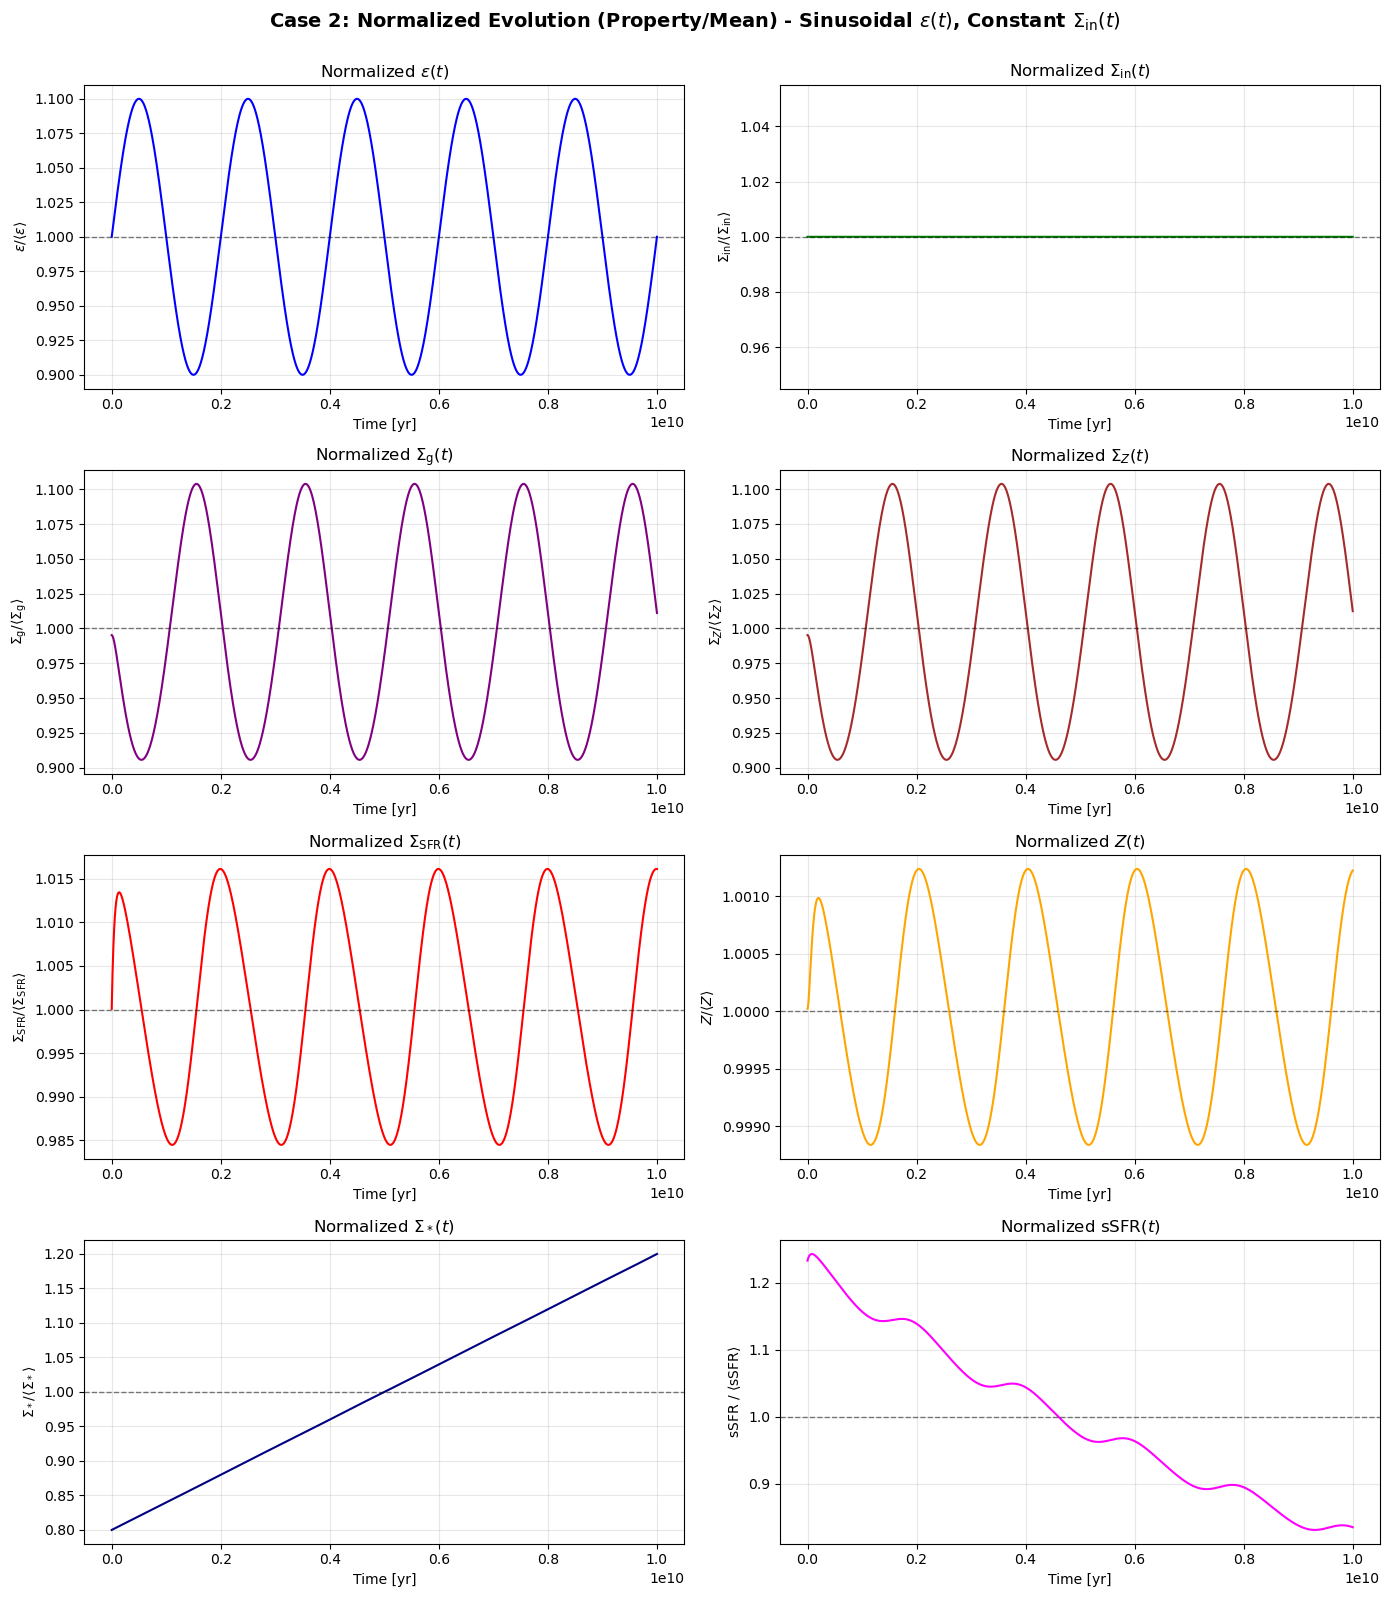


Mean values for Case 2:
  <epsilon> = 1.000000e-08 1/yr
  <Sigma_in> = 1.000000e-03 M_sol/yr/kpc^2
  <Sigma_g> = 5.024172e+04 M_sol/kpc^2
  <Sigma_Z> = 1.632806e+04 M_sol/kpc^2
  <Sigma_SFR> = 4.999600e-04 M_sol/yr/kpc^2
  <Z> = 0.324993 Z_sol
  <Sigma_star> = 1.249988e+07 M_sol/kpc^2
  <sSFR> = 4.054386e-11 1/yr


In [10]:
## Plot normalized evolution (property/mean) for Case 2: sinusoidal epsilon, constant Sigma_in

# Create figure with 8 subplots (4 rows x 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# 1. epsilon/mean(epsilon)
axes[0].plot(t_array_sin_epsilon_const_Sigma_in, 
             epsilon_array_sin_epsilon_const_Sigma_in / np.mean(epsilon_array_sin_epsilon_const_Sigma_in), 
             'b-', linewidth=1.5)
axes[0].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon / \langle\epsilon\rangle$')
axes[0].set_title(r'Normalized $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in/mean(Sigma_in)
axes[1].plot(t_array_sin_epsilon_const_Sigma_in, 
             Sigma_in_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_in_array_sin_epsilon_const_Sigma_in), 
             'g-', linewidth=1.5)
axes[1].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in} / \langle\Sigma_{\rm in}\rangle$')
axes[1].set_title(r'Normalized $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g/mean(Sigma_g)
axes[2].plot(t_array_sin_epsilon_const_Sigma_in, 
             Sigma_g_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_g_array_sin_epsilon_const_Sigma_in), 
             'purple', linewidth=1.5)
axes[2].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g} / \langle\Sigma_{\rm g}\rangle$')
axes[2].set_title(r'Normalized $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z/mean(Sigma_Z)
axes[3].plot(t_array_sin_epsilon_const_Sigma_in, 
             Sigma_Z_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_Z_array_sin_epsilon_const_Sigma_in), 
             'brown', linewidth=1.5)
axes[3].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z / \langle\Sigma_Z\rangle$')
axes[3].set_title(r'Normalized $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR/mean(Sigma_SFR)
axes[4].plot(t_array_sin_epsilon_const_Sigma_in, 
             Sigma_SFR_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_SFR_array_sin_epsilon_const_Sigma_in), 
             'red', linewidth=1.5)
axes[4].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR} / \langle\Sigma_{\rm SFR}\rangle$')
axes[4].set_title(r'Normalized $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z/mean(Z)
axes[5].plot(t_array_sin_epsilon_const_Sigma_in, 
             Z_array_sin_epsilon_const_Sigma_in / np.mean(Z_array_sin_epsilon_const_Sigma_in), 
             'orange', linewidth=1.5)
axes[5].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z / \langle Z\rangle$')
axes[5].set_title(r'Normalized $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star/mean(Sigma_star)
axes[6].plot(t_array_sin_epsilon_const_Sigma_in, 
             Sigma_star_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_star_array_sin_epsilon_const_Sigma_in), 
             'navy', linewidth=1.5)
axes[6].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_* / \langle\Sigma_*\rangle$')
axes[6].set_title(r'Normalized $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR/mean(sSFR)
axes[7].plot(t_array_sin_epsilon_const_Sigma_in, 
             sSFR_array_sin_epsilon_const_Sigma_in / np.mean(sSFR_array_sin_epsilon_const_Sigma_in), 
             'magenta', linewidth=1.5)
axes[7].axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR / $\langle$sSFR$\rangle$')
axes[7].set_title(r'Normalized sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Case 2: Normalized Evolution (Property/Mean) - Sinusoidal $\\epsilon(t)$, Constant $\\Sigma_{\\rm in}(t)$', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nMean values for Case 2:")
print(f"  <epsilon> = {np.mean(epsilon_array_sin_epsilon_const_Sigma_in):.6e} 1/yr")
print(f"  <Sigma_in> = {np.mean(Sigma_in_array_sin_epsilon_const_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Sigma_g> = {np.mean(Sigma_g_array_sin_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_Z> = {np.mean(Sigma_Z_array_sin_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_SFR> = {np.mean(Sigma_SFR_array_sin_epsilon_const_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Z> = {np.mean(Z_array_sin_epsilon_const_Sigma_in):.6f} Z_sol")
print(f"  <Sigma_star> = {np.mean(Sigma_star_array_sin_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <sSFR> = {np.mean(sSFR_array_sin_epsilon_const_Sigma_in):.6e} 1/yr")


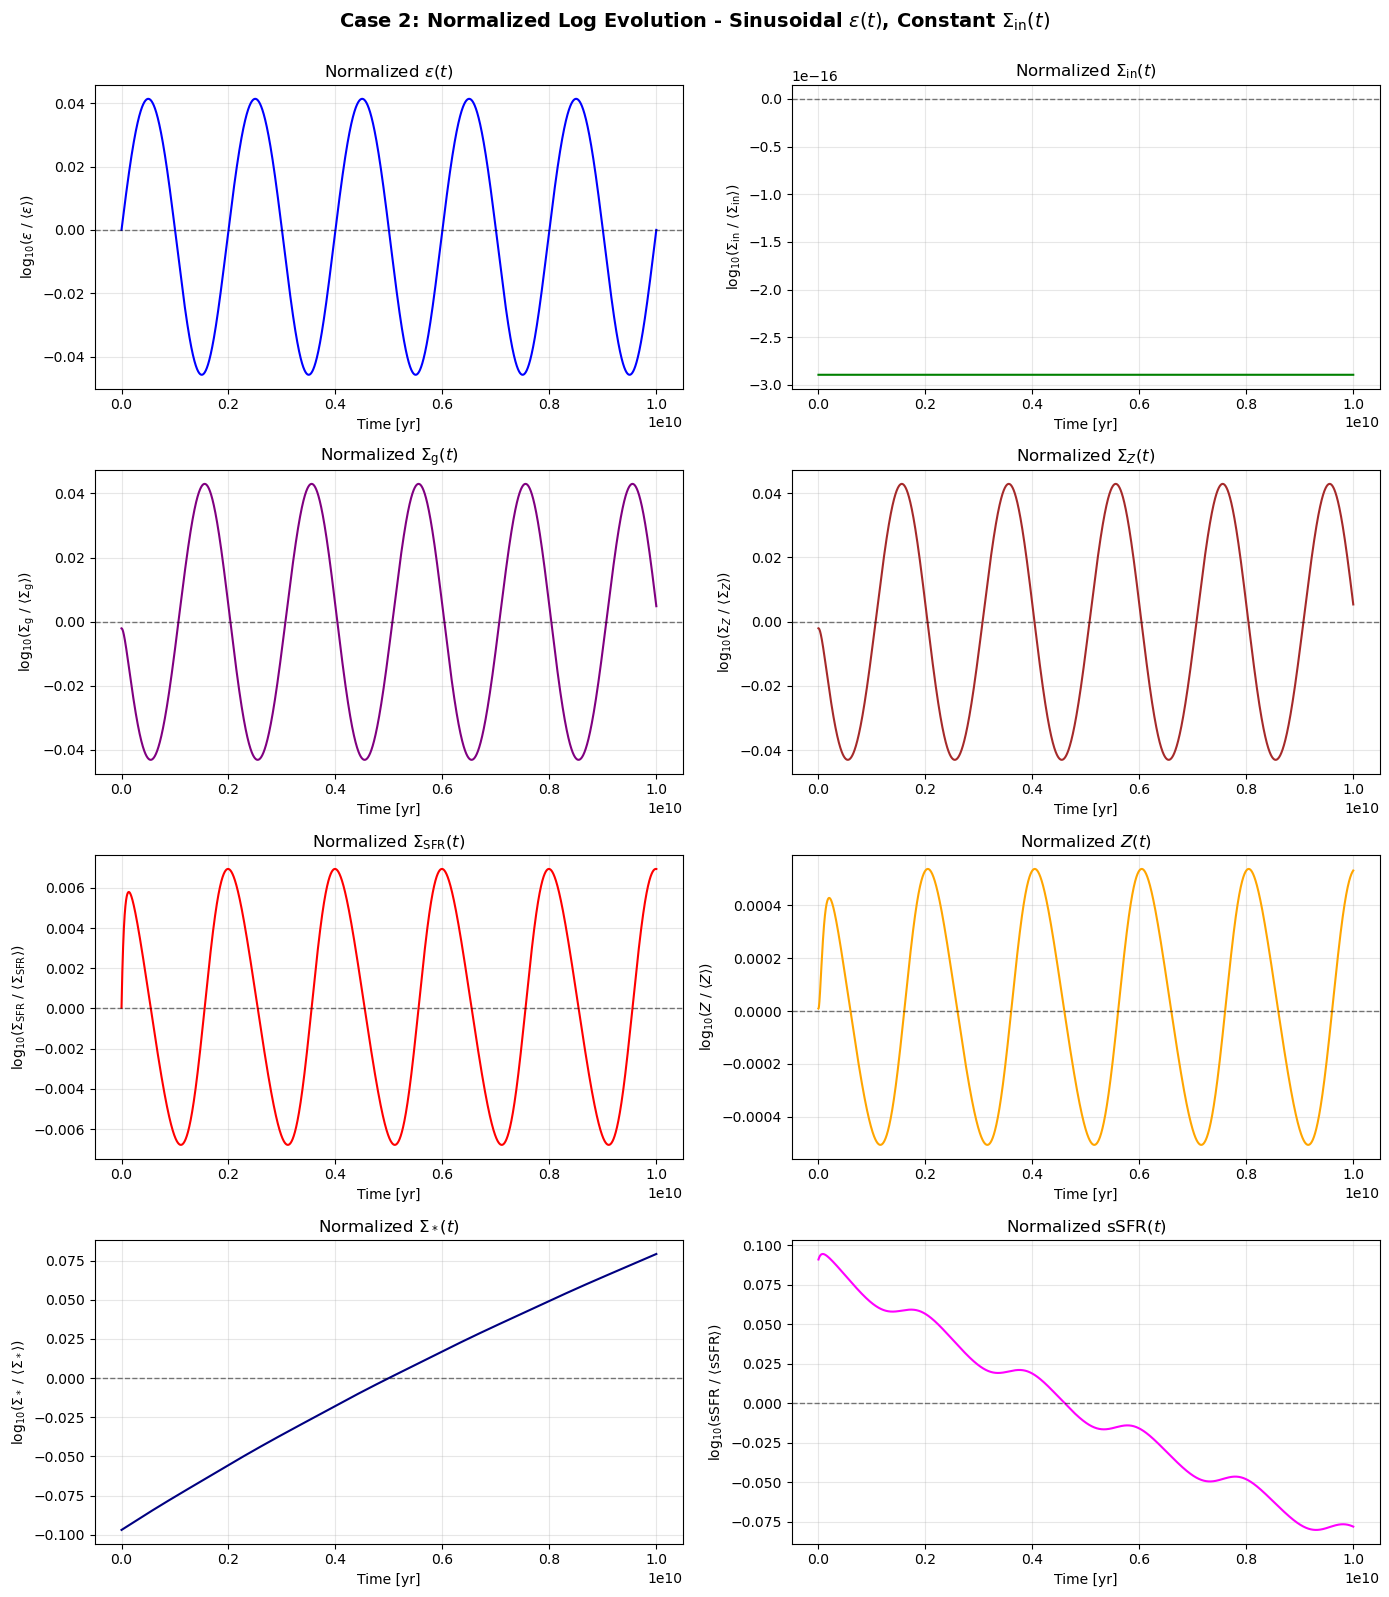


Mean values for Case 2:
  <epsilon> = 1.000000e-08 1/yr
  <Sigma_in> = 1.000000e-03 M_sol/yr/kpc^2
  <Sigma_g> = 5.024172e+04 M_sol/kpc^2
  <Sigma_Z> = 1.632806e+04 M_sol/kpc^2
  <Sigma_SFR> = 4.999600e-04 M_sol/yr/kpc^2
  <Z> = 0.324993 Z_sol
  <Sigma_star> = 1.249988e+07 M_sol/kpc^2
  <sSFR> = 4.054386e-11 1/yr


In [11]:
## Plot normalized evolution (property/mean) for Case 2: sinusoidal epsilon, constant Sigma_in
## Using log scale: log10(quantity / <quantity>)

# Create figure with 8 subplots (4 rows x 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# 1. log10(epsilon / <epsilon>)
axes[0].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(epsilon_array_sin_epsilon_const_Sigma_in / np.mean(epsilon_array_sin_epsilon_const_Sigma_in)), 
             'b-', linewidth=1.5)
axes[0].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'log$_{10}$($\epsilon$ / $\langle\epsilon\rangle$)')
axes[0].set_title(r'Normalized $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. log10(Sigma_in / <Sigma_in>)
axes[1].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(Sigma_in_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_in_array_sin_epsilon_const_Sigma_in)), 
             'g-', linewidth=1.5)
axes[1].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'log$_{10}$($\Sigma_{\rm in}$ / $\langle\Sigma_{\rm in}\rangle$)')
axes[1].set_title(r'Normalized $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. log10(Sigma_g / <Sigma_g>)
axes[2].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(Sigma_g_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_g_array_sin_epsilon_const_Sigma_in)), 
             'purple', linewidth=1.5)
axes[2].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'log$_{10}$($\Sigma_{\rm g}$ / $\langle\Sigma_{\rm g}\rangle$)')
axes[2].set_title(r'Normalized $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. log10(Sigma_Z / <Sigma_Z>)
axes[3].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(Sigma_Z_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_Z_array_sin_epsilon_const_Sigma_in)), 
             'brown', linewidth=1.5)
axes[3].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'log$_{10}$($\Sigma_Z$ / $\langle\Sigma_Z\rangle$)')
axes[3].set_title(r'Normalized $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. log10(Sigma_SFR / <Sigma_SFR>)
axes[4].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(Sigma_SFR_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_SFR_array_sin_epsilon_const_Sigma_in)), 
             'red', linewidth=1.5)
axes[4].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$ / $\langle\Sigma_{\rm SFR}\rangle$)')
axes[4].set_title(r'Normalized $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. log10(Z / <Z>)
axes[5].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(Z_array_sin_epsilon_const_Sigma_in / np.mean(Z_array_sin_epsilon_const_Sigma_in)), 
             'orange', linewidth=1.5)
axes[5].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'log$_{10}$($Z$ / $\langle Z\rangle$)')
axes[5].set_title(r'Normalized $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. log10(Sigma_star / <Sigma_star>)
axes[6].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(Sigma_star_array_sin_epsilon_const_Sigma_in / np.mean(Sigma_star_array_sin_epsilon_const_Sigma_in)), 
             'navy', linewidth=1.5)
axes[6].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'log$_{10}$($\Sigma_*$ / $\langle\Sigma_*\rangle$)')
axes[6].set_title(r'Normalized $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. log10(sSFR / <sSFR>)
axes[7].plot(t_array_sin_epsilon_const_Sigma_in, 
             np.log10(sSFR_array_sin_epsilon_const_Sigma_in / np.mean(sSFR_array_sin_epsilon_const_Sigma_in)), 
             'magenta', linewidth=1.5)
axes[7].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'log$_{10}$(sSFR / $\langle$sSFR$\rangle$)')
axes[7].set_title(r'Normalized sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Case 2: Normalized Log Evolution - Sinusoidal $\\epsilon(t)$, Constant $\\Sigma_{\\rm in}(t)$', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nMean values for Case 2:")
print(f"  <epsilon> = {np.mean(epsilon_array_sin_epsilon_const_Sigma_in):.6e} 1/yr")
print(f"  <Sigma_in> = {np.mean(Sigma_in_array_sin_epsilon_const_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Sigma_g> = {np.mean(Sigma_g_array_sin_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_Z> = {np.mean(Sigma_Z_array_sin_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_SFR> = {np.mean(Sigma_SFR_array_sin_epsilon_const_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Z> = {np.mean(Z_array_sin_epsilon_const_Sigma_in):.6f} Z_sol")
print(f"  <Sigma_star> = {np.mean(Sigma_star_array_sin_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <sSFR> = {np.mean(sSFR_array_sin_epsilon_const_Sigma_in):.6e} 1/yr")

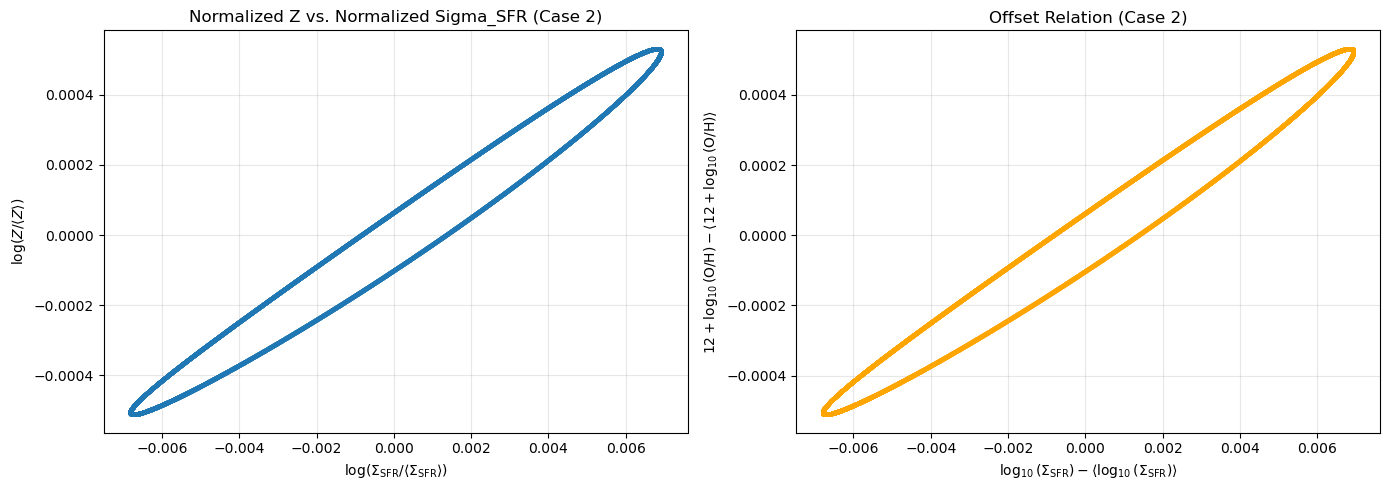

In [12]:
# Create boolean mask for stable region (0.4e10 yr to 0.6e10 yr)
mask_stable = (t_array_sin_epsilon_const_Sigma_in >= 0.4e10) * (t_array_sin_epsilon_const_Sigma_in <= 0.6e10)

# Calculate offsets
offset_OH = OH_array_sin_epsilon_const_Sigma_in[mask_stable] - np.mean(OH_array_sin_epsilon_const_Sigma_in[mask_stable])
offset_log10_Sigma_SFR = (np.log10(Sigma_SFR_array_sin_epsilon_const_Sigma_in[mask_stable]) - 
                           np.mean(np.log10(Sigma_SFR_array_sin_epsilon_const_Sigma_in[mask_stable])))

# Create figure with 2 subplots (1 row x 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: log(Z/<Z>) vs log(Sigma_SFR/<Sigma_SFR>)
axes[0].plot(
    np.log10(Sigma_SFR_array_sin_epsilon_const_Sigma_in[mask_stable] / 
             np.mean(Sigma_SFR_array_sin_epsilon_const_Sigma_in[mask_stable])),
    np.log10(Z_array_sin_epsilon_const_Sigma_in[mask_stable] / 
             np.mean(Z_array_sin_epsilon_const_Sigma_in[mask_stable])),
    'o', markersize=2, alpha=0.5
)
axes[0].set_xlabel(r'log($\Sigma_{\rm SFR} / \langle\Sigma_{\rm SFR}\rangle$)')
axes[0].set_ylabel(r'log($Z / \langle Z\rangle$)')
axes[0].set_title('Normalized Z vs. Normalized Sigma_SFR (Case 2)')
axes[0].grid(True, alpha=0.3)

# Right plot: offset vs offset
axes[1].plot(offset_log10_Sigma_SFR, offset_OH, 'o', markersize=2, alpha=0.5, color='orange')
axes[1].set_xlabel(r'$\log_{10}(\Sigma_{\rm SFR}) - \langle\log_{10}(\Sigma_{\rm SFR})\rangle$')
axes[1].set_ylabel(r'$12+\log_{10}({\rm O/H}) - \langle 12+\log_{10}({\rm O/H})\rangle$')
axes[1].set_title('Offset Relation (Case 2)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20251103 Case 3: sinusoidal variation of $\Sigma_\mathrm{in}[t]$ and constant $\epsilon[t]$

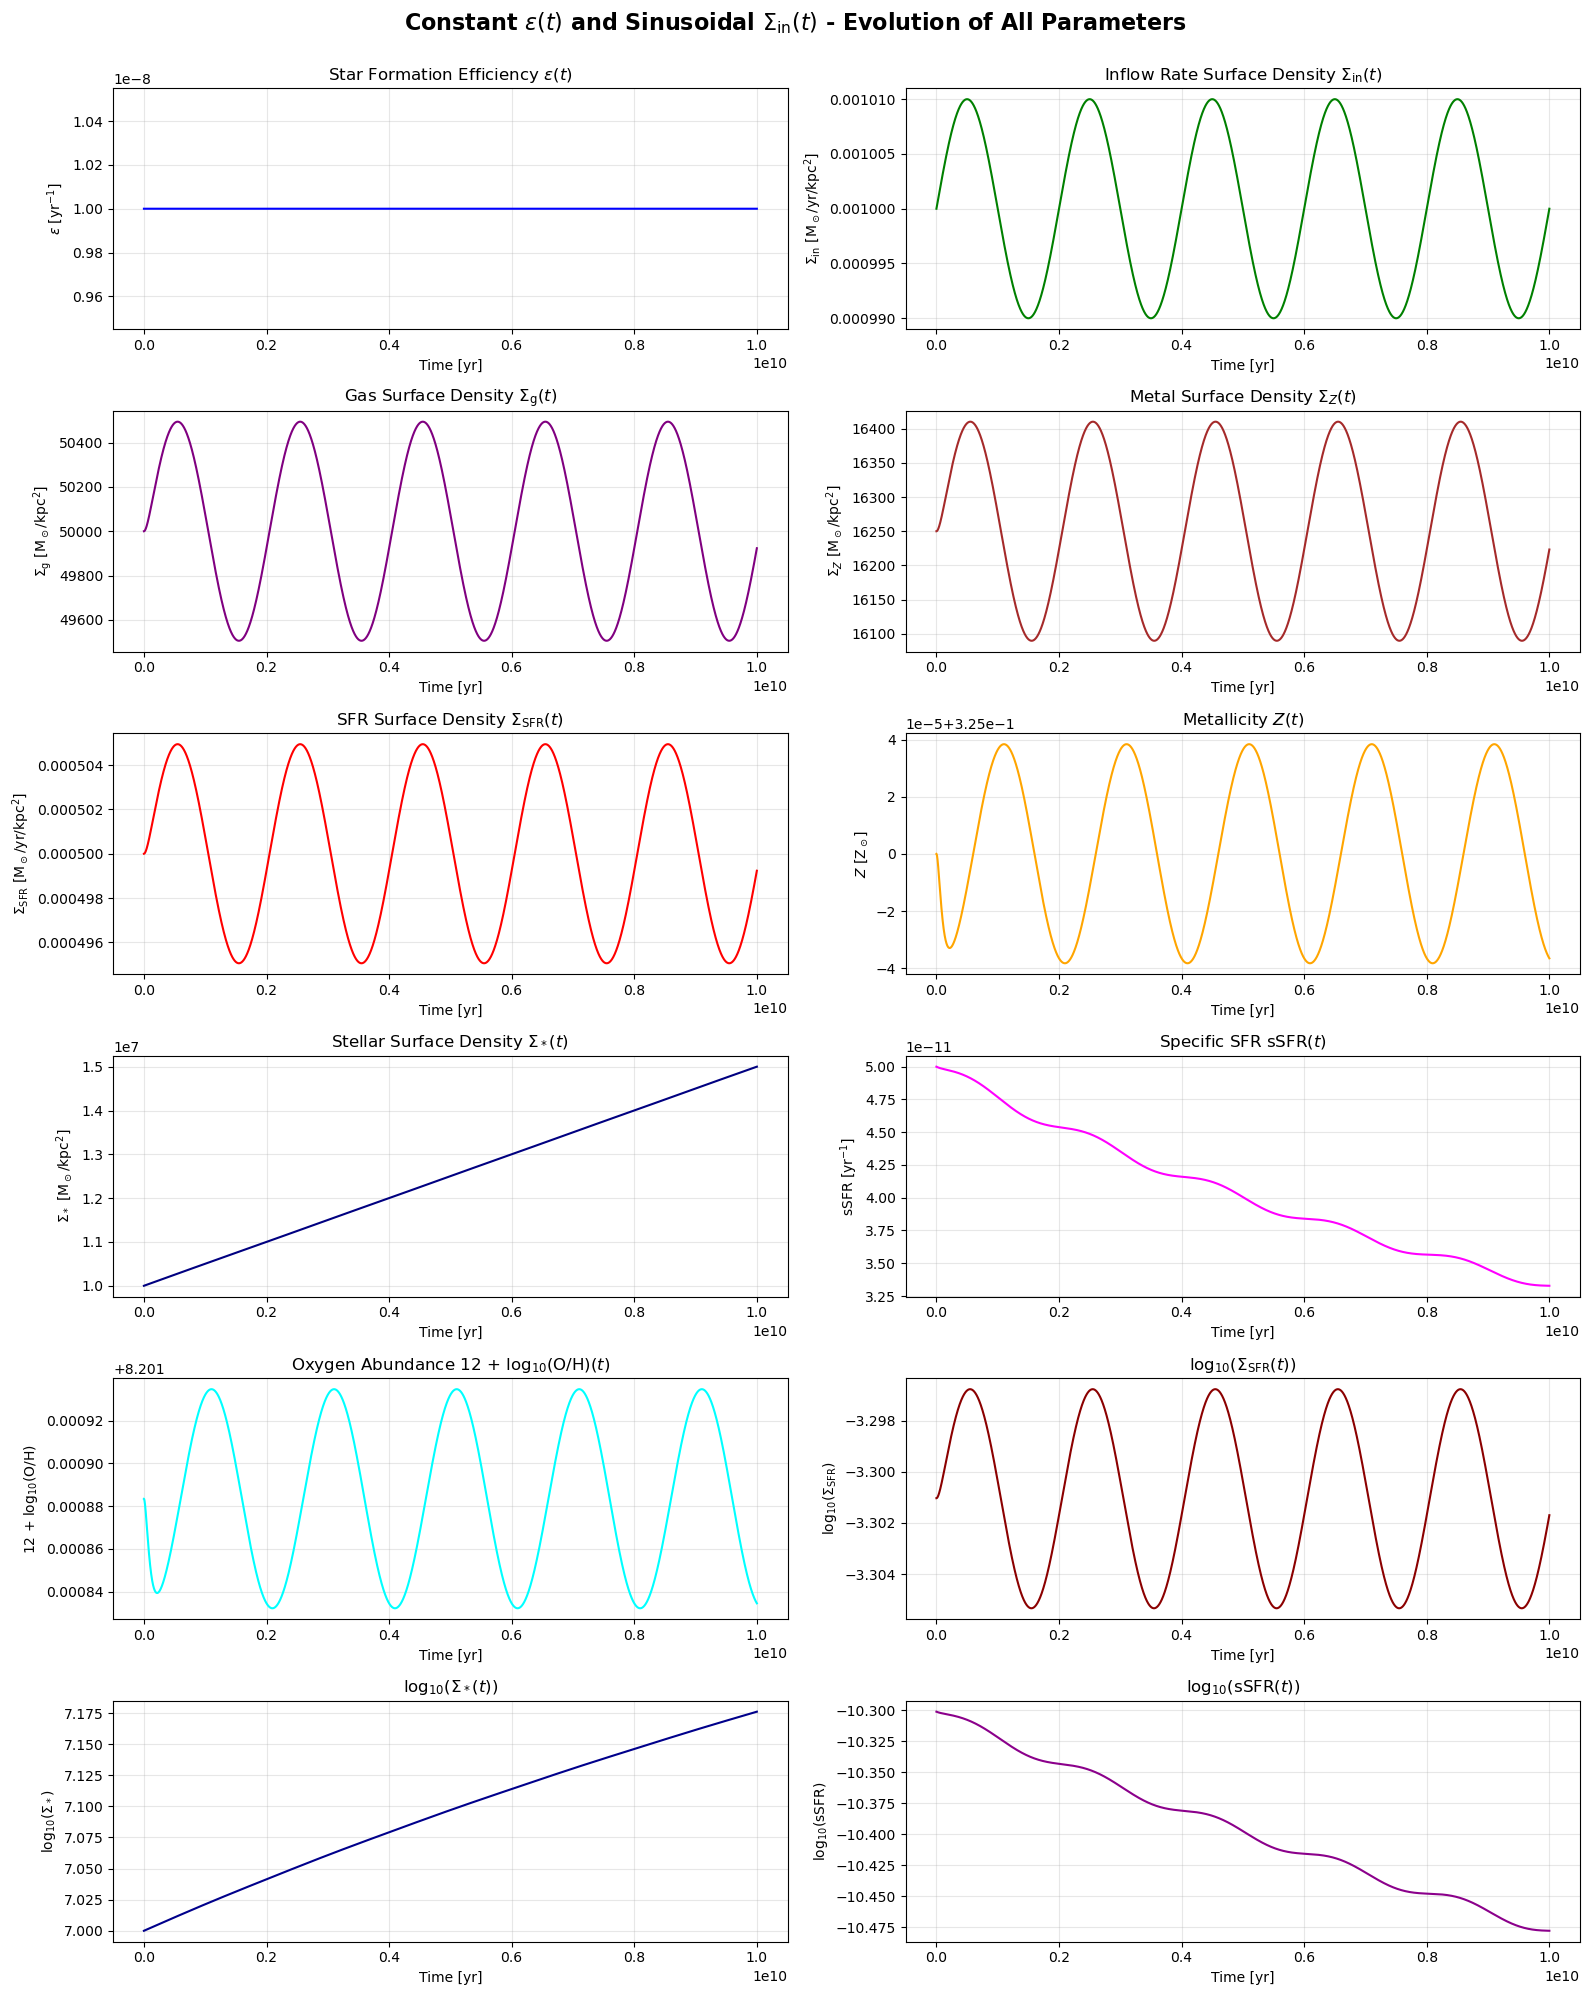


Summary of Case 4.3 evolution:
  Initial Z = 0.325000 Z_sol
  Final Z = 0.324963 Z_sol


In [13]:
## Visualization of all 12 parameters evolution for Case that constant epsilon and sinusoidal Sigma_in

# Create figure with 12 subplots (6 rows x 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
axes = axes.flatten()

# 1. epsilon[t]
axes[0].plot(t_array_const_epsilon_sin_Sigma_in, epsilon_array_const_epsilon_sin_Sigma_in, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t_array_const_epsilon_sin_Sigma_in, Sigma_in_array_const_epsilon_sin_Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t_array_const_epsilon_sin_Sigma_in, Sigma_g_array_const_epsilon_sin_Sigma_in, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t_array_const_epsilon_sin_Sigma_in, Sigma_Z_array_const_epsilon_sin_Sigma_in, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t_array_const_epsilon_sin_Sigma_in, Sigma_SFR_array_const_epsilon_sin_Sigma_in, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t_array_const_epsilon_sin_Sigma_in, Z_array_const_epsilon_sin_Sigma_in, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t_array_const_epsilon_sin_Sigma_in, Sigma_star_array_const_epsilon_sin_Sigma_in, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t_array_const_epsilon_sin_Sigma_in, sSFR_array_const_epsilon_sin_Sigma_in, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t_array_const_epsilon_sin_Sigma_in, OH_array_const_epsilon_sin_Sigma_in, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t_array_const_epsilon_sin_Sigma_in, log10_Sigma_SFR_array_const_epsilon_sin_Sigma_in, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t_array_const_epsilon_sin_Sigma_in, log10_Sigma_star_array_const_epsilon_sin_Sigma_in, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t_array_const_epsilon_sin_Sigma_in, log10_sSFR_array_const_epsilon_sin_Sigma_in, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Constant $\\epsilon(t)$ and Sinusoidal $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 4.3 evolution:")
print(f"  Initial Z = {Z_array_const_epsilon_sin_Sigma_in[0]:.6f} Z_sol")
print(f"  Final Z = {Z_array_const_epsilon_sin_Sigma_in[-1]:.6f} Z_sol")

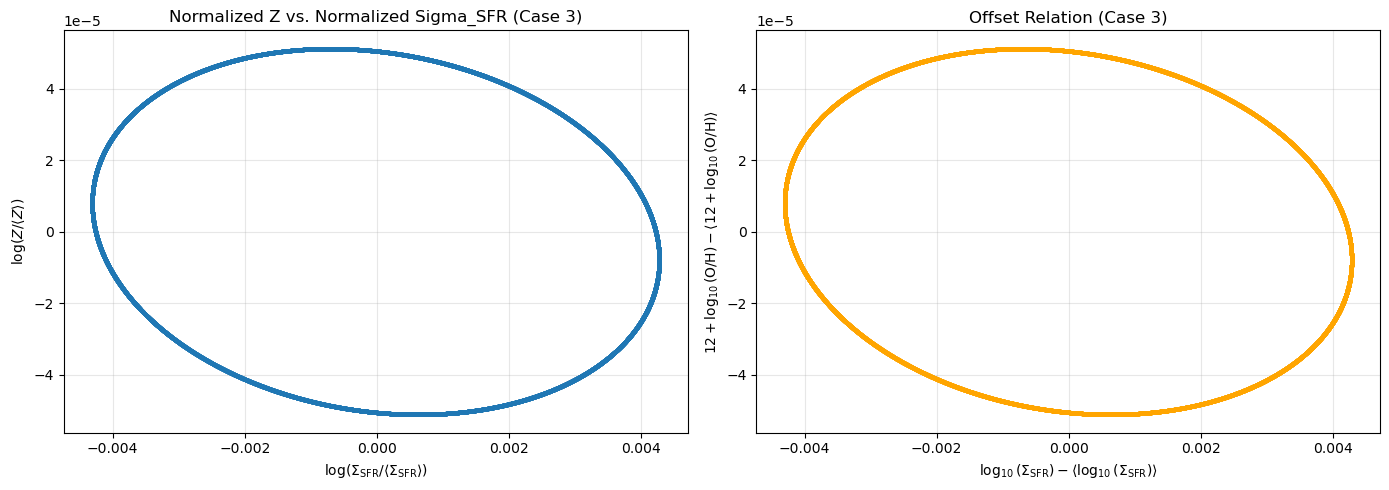

In [14]:
# Create boolean mask for stable region (0.4e10 yr to 0.6e10 yr)
mask_stable = (t_array_const_epsilon_sin_Sigma_in >= 0.4e10) * (t_array_const_epsilon_sin_Sigma_in <= 0.6e10)

# Calculate offsets
offset_OH = OH_array_const_epsilon_sin_Sigma_in[mask_stable] - np.mean(OH_array_const_epsilon_sin_Sigma_in[mask_stable])
offset_log10_Sigma_SFR = (np.log10(Sigma_SFR_array_const_epsilon_sin_Sigma_in[mask_stable]) - 
                           np.mean(np.log10(Sigma_SFR_array_const_epsilon_sin_Sigma_in[mask_stable])))

# Create figure with 2 subplots (1 row x 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: log(Z/<Z>) vs log(Sigma_SFR/<Sigma_SFR>)
axes[0].plot(
    np.log10(Sigma_SFR_array_const_epsilon_sin_Sigma_in[mask_stable] / 
             np.mean(Sigma_SFR_array_const_epsilon_sin_Sigma_in[mask_stable])),
    np.log10(Z_array_const_epsilon_sin_Sigma_in[mask_stable] / 
             np.mean(Z_array_const_epsilon_sin_Sigma_in[mask_stable])),
    'o', markersize=2, alpha=0.5
)
axes[0].set_xlabel(r'log($\Sigma_{\rm SFR} / \langle\Sigma_{\rm SFR}\rangle$)')
axes[0].set_ylabel(r'log($Z / \langle Z\rangle$)')
axes[0].set_title('Normalized Z vs. Normalized Sigma_SFR (Case 3)')
axes[0].grid(True, alpha=0.3)

# Right plot: offset vs offset
axes[1].plot(offset_log10_Sigma_SFR, offset_OH, 'o', markersize=2, alpha=0.5, color='orange')
axes[1].set_xlabel(r'$\log_{10}(\Sigma_{\rm SFR}) - \langle\log_{10}(\Sigma_{\rm SFR})\rangle$')
axes[1].set_ylabel(r'$12+\log_{10}({\rm O/H}) - \langle 12+\log_{10}({\rm O/H})\rangle$')
axes[1].set_title('Offset Relation (Case 3)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20251105 Case 4: sinusoidal variation of $\Sigma_\mathrm{in}[t]$ and sinusoidal $\epsilon[t]$

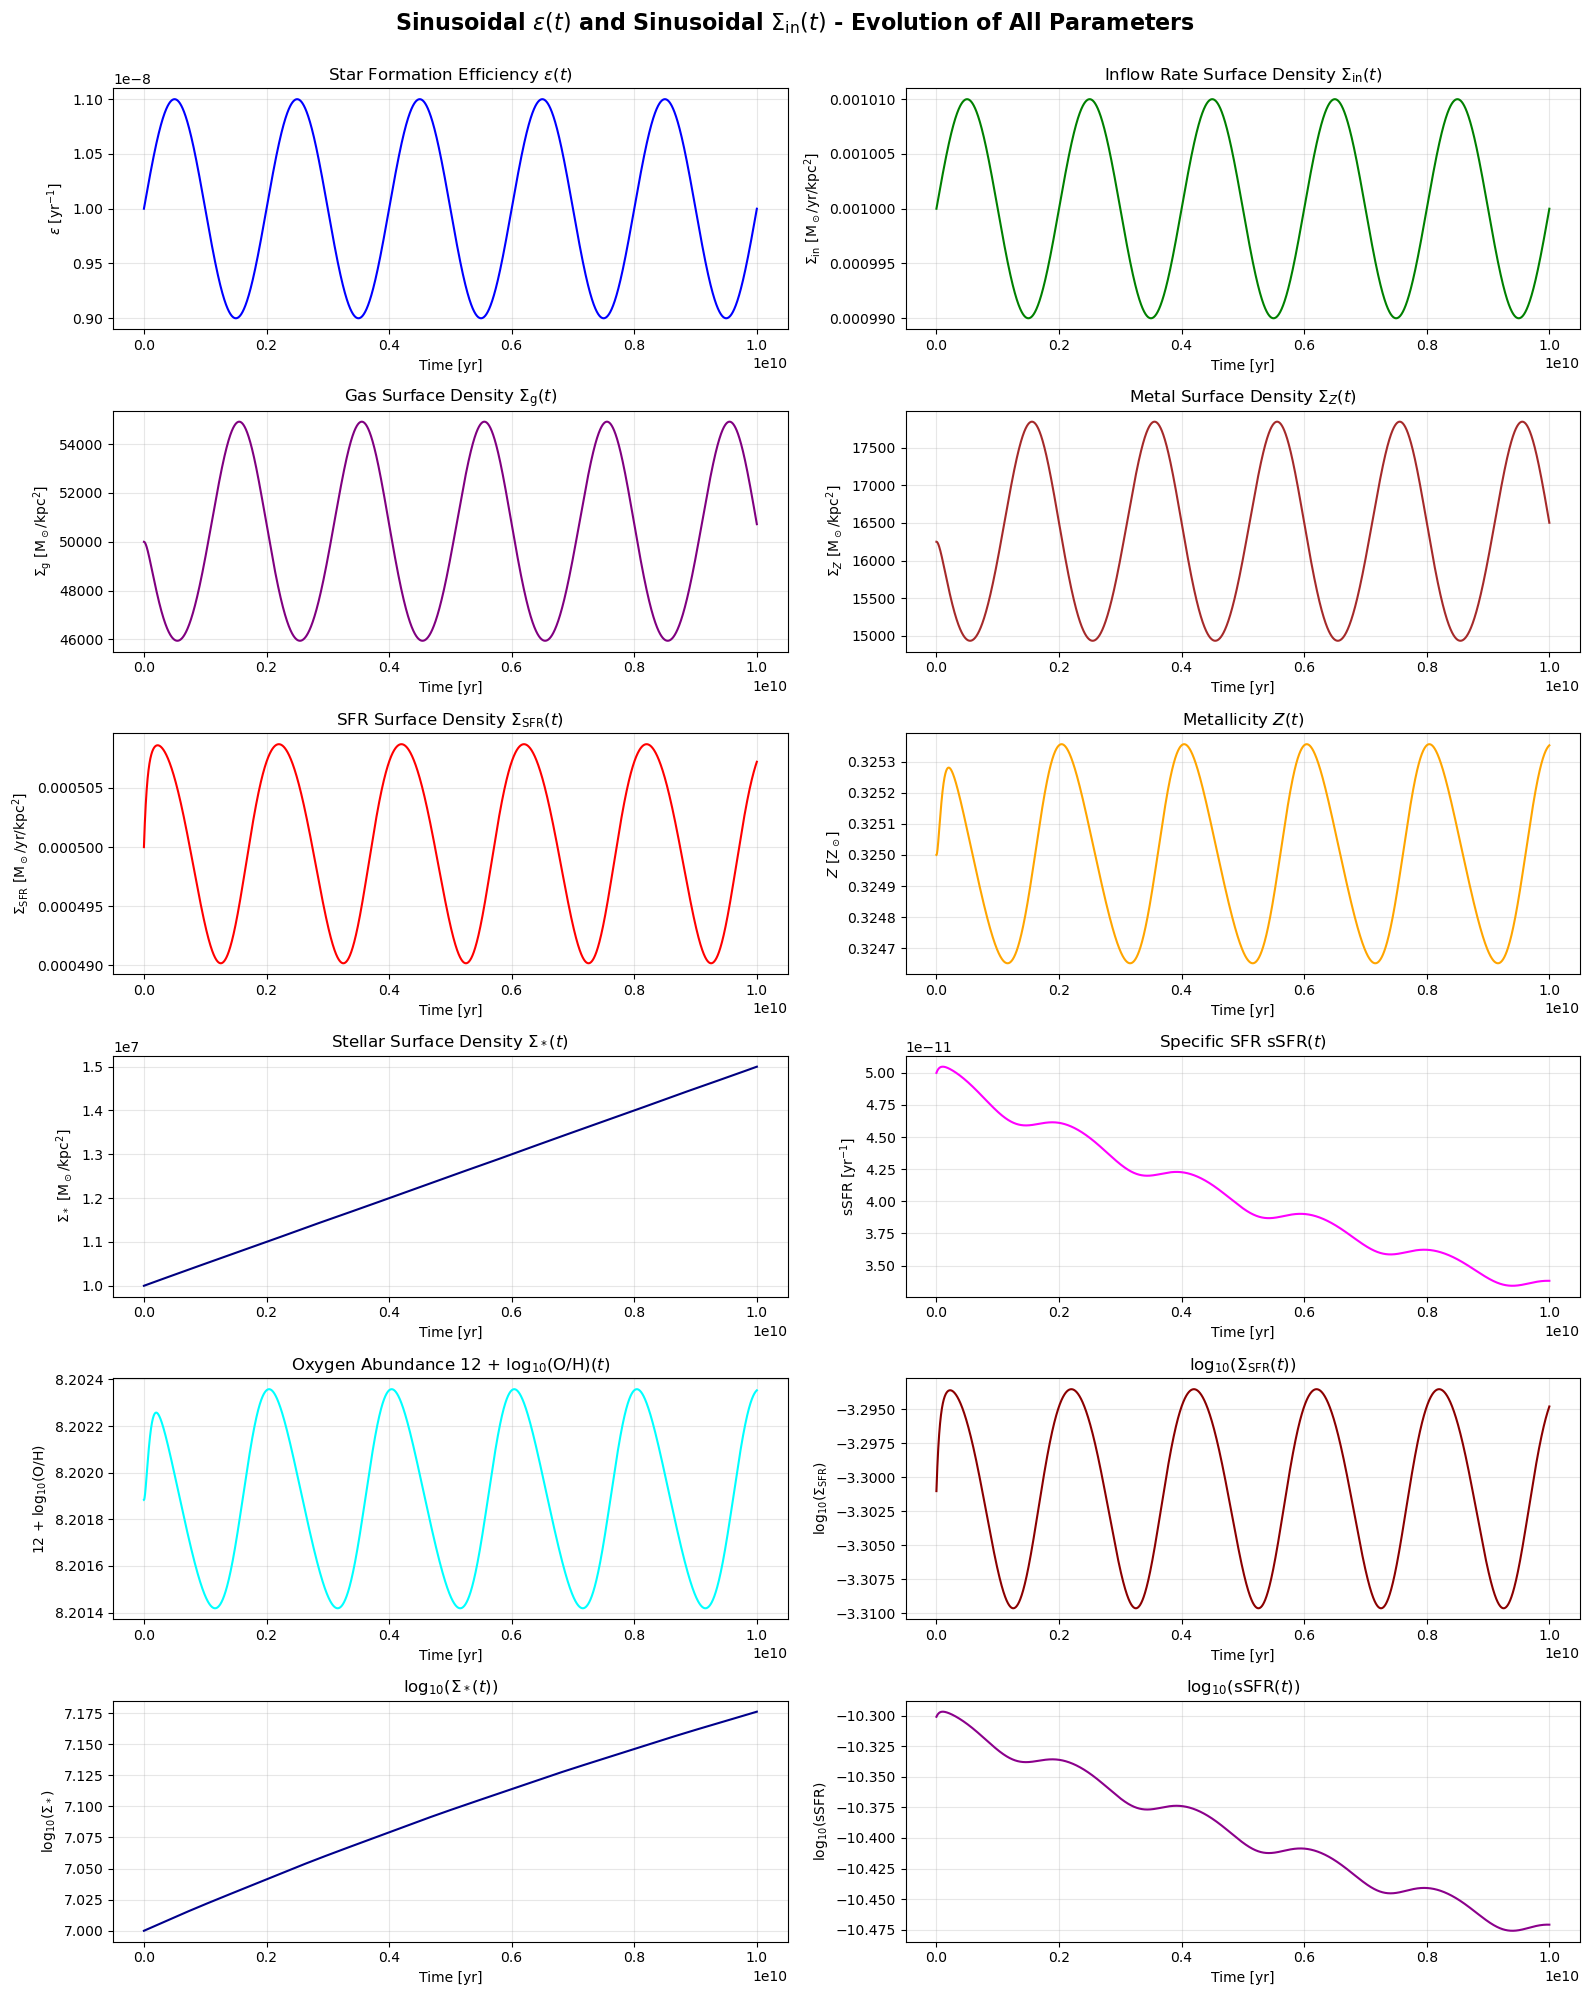


Summary of Case 4 evolution:
  Initial Z = 0.325000 Z_sol
  Final Z = 0.325352 Z_sol


In [15]:
## Visualization of all 12 parameters evolution for Case 4: sinusoidal Sigma_in and sinusoidal epsilon

# Create figure with 12 subplots (6 rows x 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
axes = axes.flatten()

# 1. epsilon[t]
axes[0].plot(t_array_sin_epsilon_sin_Sigma_in, epsilon_array_sin_epsilon_sin_Sigma_in, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t_array_sin_epsilon_sin_Sigma_in, Sigma_in_array_sin_epsilon_sin_Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t_array_sin_epsilon_sin_Sigma_in, Sigma_g_array_sin_epsilon_sin_Sigma_in, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t_array_sin_epsilon_sin_Sigma_in, Sigma_Z_array_sin_epsilon_sin_Sigma_in, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t_array_sin_epsilon_sin_Sigma_in, Sigma_SFR_array_sin_epsilon_sin_Sigma_in, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t_array_sin_epsilon_sin_Sigma_in, Z_array_sin_epsilon_sin_Sigma_in, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t_array_sin_epsilon_sin_Sigma_in, Sigma_star_array_sin_epsilon_sin_Sigma_in, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t_array_sin_epsilon_sin_Sigma_in, sSFR_array_sin_epsilon_sin_Sigma_in, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t_array_sin_epsilon_sin_Sigma_in, OH_array_sin_epsilon_sin_Sigma_in, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t_array_sin_epsilon_sin_Sigma_in, log10_Sigma_SFR_array_sin_epsilon_sin_Sigma_in, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t_array_sin_epsilon_sin_Sigma_in, log10_Sigma_star_array_sin_epsilon_sin_Sigma_in, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t_array_sin_epsilon_sin_Sigma_in, log10_sSFR_array_sin_epsilon_sin_Sigma_in, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Sinusoidal $\\epsilon(t)$ and Sinusoidal $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 4 evolution:")
print(f"  Initial Z = {Z_array_sin_epsilon_sin_Sigma_in[0]:.6f} Z_sol")
print(f"  Final Z = {Z_array_sin_epsilon_sin_Sigma_in[-1]:.6f} Z_sol")

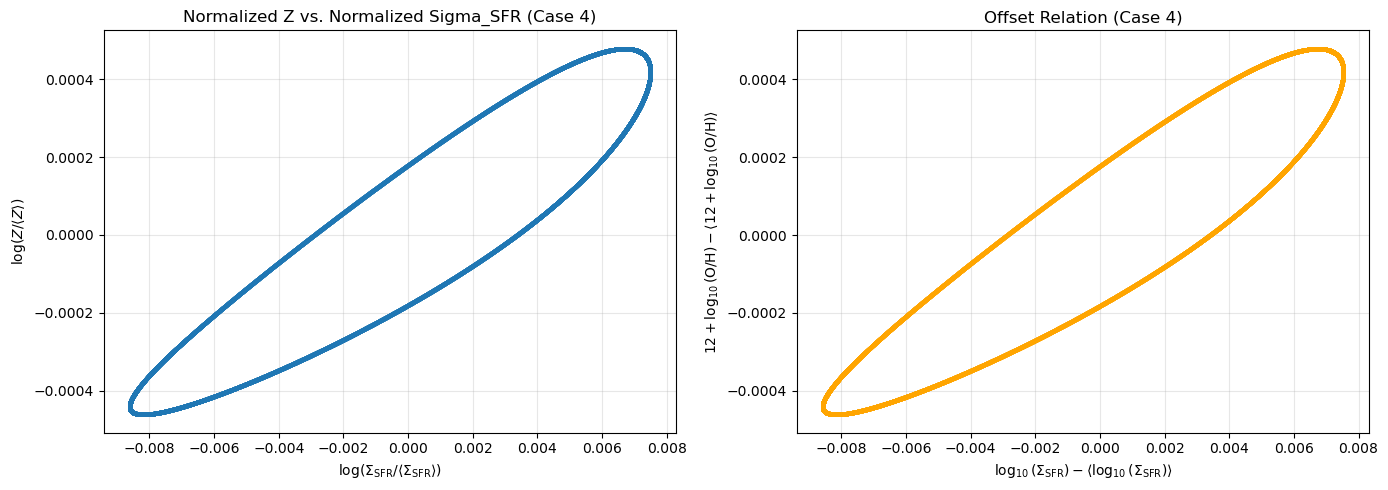

In [16]:
# Create boolean mask for stable region (0.4e10 yr to 0.6e10 yr)
mask_stable = (t_array_sin_epsilon_sin_Sigma_in >= 0.4e10) * (t_array_sin_epsilon_sin_Sigma_in <= 0.6e10)

# Calculate offsets
offset_OH = OH_array_sin_epsilon_sin_Sigma_in[mask_stable] - np.mean(OH_array_sin_epsilon_sin_Sigma_in[mask_stable])
offset_log10_Sigma_SFR = (np.log10(Sigma_SFR_array_sin_epsilon_sin_Sigma_in[mask_stable]) - 
                           np.mean(np.log10(Sigma_SFR_array_sin_epsilon_sin_Sigma_in[mask_stable])))

# Create figure with 2 subplots (1 row x 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: log(Z/<Z>) vs log(Sigma_SFR/<Sigma_SFR>)
axes[0].plot(
    np.log10(Sigma_SFR_array_sin_epsilon_sin_Sigma_in[mask_stable] / 
             np.mean(Sigma_SFR_array_sin_epsilon_sin_Sigma_in[mask_stable])),
    np.log10(Z_array_sin_epsilon_sin_Sigma_in[mask_stable] / 
             np.mean(Z_array_sin_epsilon_sin_Sigma_in[mask_stable])),
    'o', markersize=2, alpha=0.5
)
axes[0].set_xlabel(r'log($\Sigma_{\rm SFR} / \langle\Sigma_{\rm SFR}\rangle$)')
axes[0].set_ylabel(r'log($Z / \langle Z\rangle$)')
axes[0].set_title('Normalized Z vs. Normalized Sigma_SFR (Case 4)')
axes[0].grid(True, alpha=0.3)

# Right plot: offset vs offset
axes[1].plot(offset_log10_Sigma_SFR, offset_OH, 'o', markersize=2, alpha=0.5, color='orange')
axes[1].set_xlabel(r'$\log_{10}(\Sigma_{\rm SFR}) - \langle\log_{10}(\Sigma_{\rm SFR})\rangle$')
axes[1].set_ylabel(r'$12+\log_{10}({\rm O/H}) - \langle 12+\log_{10}({\rm O/H})\rangle$')
axes[1].set_title('Offset Relation (Case 4)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20251105 Case 5: exponential decay of $\epsilon[t]$ and constant $\Sigma_\mathrm{in}[t]$

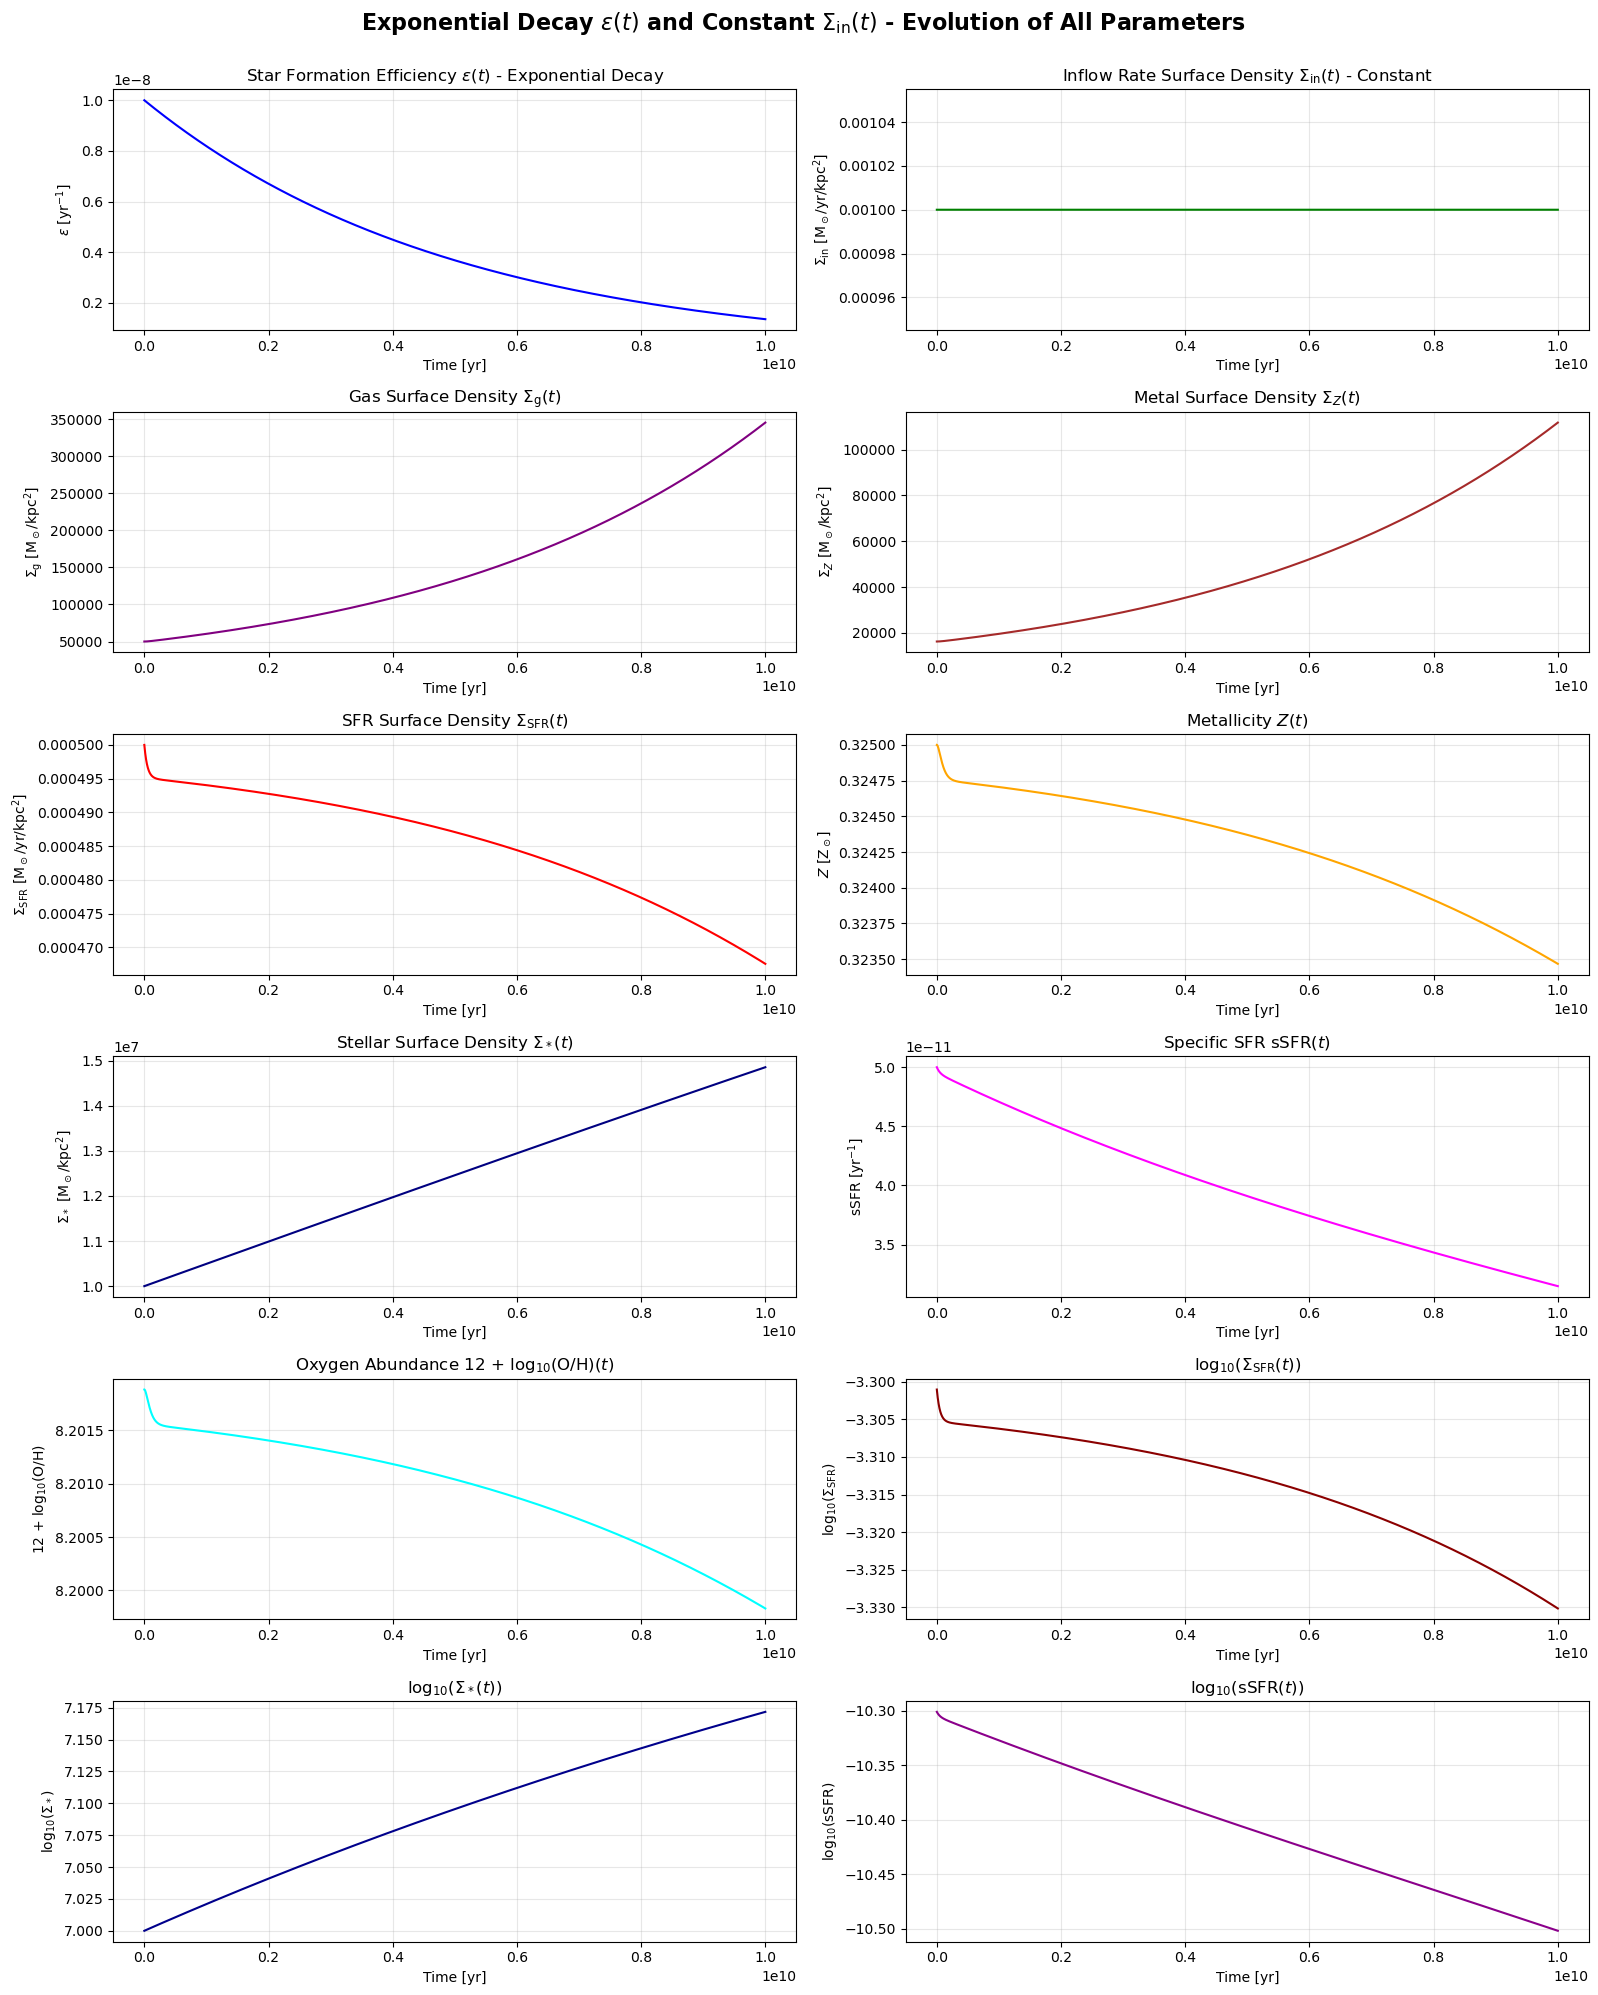


Summary of Case 5 evolution:
  Initial Z = 0.325000 Z_sol
  Final Z = 0.323467 Z_sol


In [17]:
## Visualization of all 12 parameters evolution for Case 5: exponential decay epsilon and constant Sigma_in

# Create figure with 12 subplots (6 rows x 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
axes = axes.flatten()

# 1. epsilon[t]
axes[0].plot(t_array_exp_epsilon_const_Sigma_in, epsilon_array_exp_epsilon_const_Sigma_in, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$ - Exponential Decay')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t_array_exp_epsilon_const_Sigma_in, Sigma_in_array_exp_epsilon_const_Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$ - Constant')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t_array_exp_epsilon_const_Sigma_in, Sigma_g_array_exp_epsilon_const_Sigma_in, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t_array_exp_epsilon_const_Sigma_in, Sigma_Z_array_exp_epsilon_const_Sigma_in, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t_array_exp_epsilon_const_Sigma_in, Sigma_SFR_array_exp_epsilon_const_Sigma_in, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t_array_exp_epsilon_const_Sigma_in, Z_array_exp_epsilon_const_Sigma_in, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t_array_exp_epsilon_const_Sigma_in, Sigma_star_array_exp_epsilon_const_Sigma_in, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t_array_exp_epsilon_const_Sigma_in, sSFR_array_exp_epsilon_const_Sigma_in, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t_array_exp_epsilon_const_Sigma_in, OH_array_exp_epsilon_const_Sigma_in, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t_array_exp_epsilon_const_Sigma_in, log10_Sigma_SFR_array_exp_epsilon_const_Sigma_in, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t_array_exp_epsilon_const_Sigma_in, log10_Sigma_star_array_exp_epsilon_const_Sigma_in, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t_array_exp_epsilon_const_Sigma_in, log10_sSFR_array_exp_epsilon_const_Sigma_in, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Exponential Decay $\\epsilon(t)$ and Constant $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 5 evolution:")
print(f"  Initial Z = {Z_array_exp_epsilon_const_Sigma_in[0]:.6f} Z_sol")
print(f"  Final Z = {Z_array_exp_epsilon_const_Sigma_in[-1]:.6f} Z_sol")

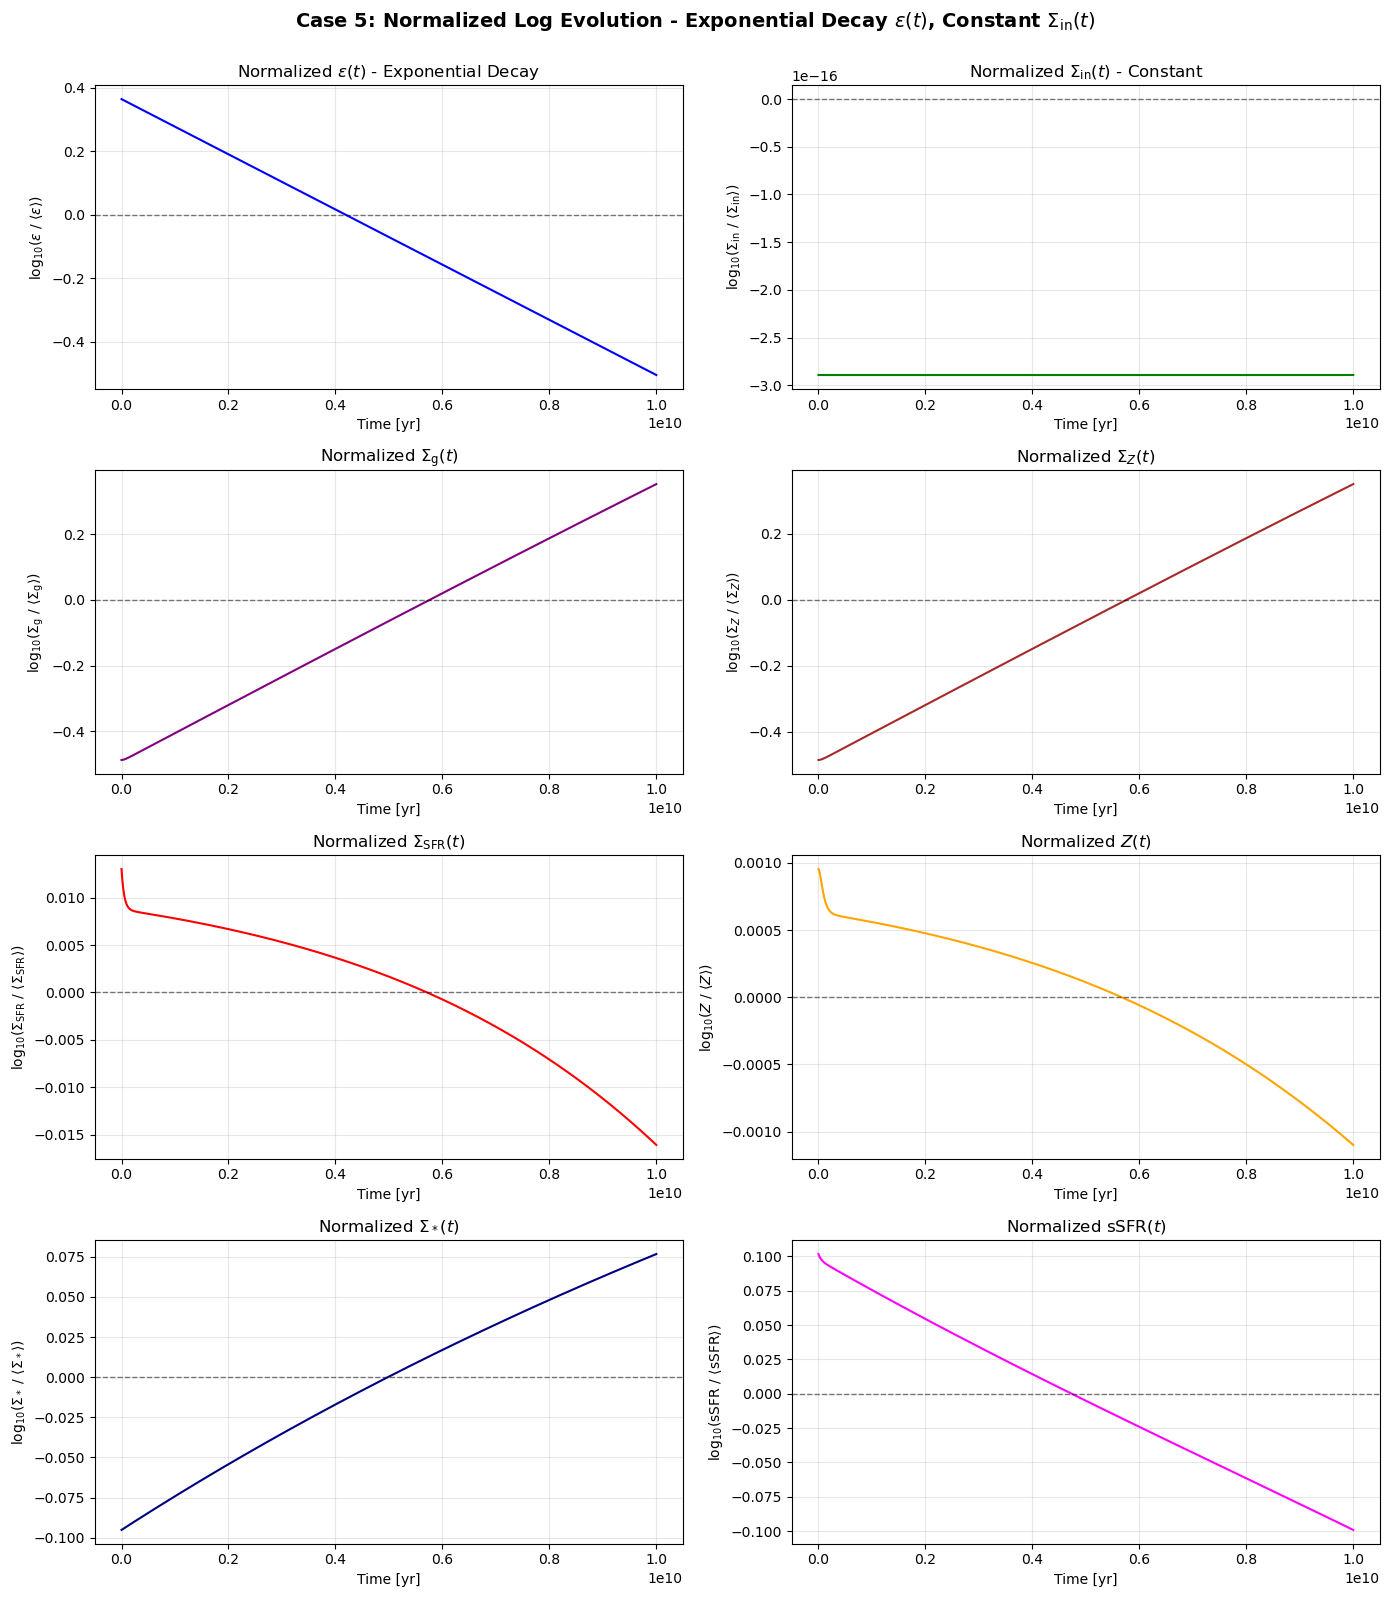


Mean values for Case 5:
  <epsilon> = 4.323337e-09 1/yr
  <Sigma_in> = 1.000000e-03 M_sol/yr/kpc^2
  <Sigma_g> = 1.536089e+05 M_sol/kpc^2
  <Sigma_Z> = 4.978261e+04 M_sol/kpc^2
  <Sigma_SFR> = 4.852254e-04 M_sol/yr/kpc^2
  <Z> = 0.324287 Z_sol
  <Sigma_star> = 1.244820e+07 M_sol/kpc^2
  <sSFR> = 3.955666e-11 1/yr


In [18]:
## Plot normalized evolution (property/mean) for Case 5: exponential decay epsilon, constant Sigma_in
## Using log scale: log10(quantity / <quantity>)

# Create figure with 8 subplots (4 rows x 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# 1. log10(epsilon / <epsilon>)
axes[0].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(epsilon_array_exp_epsilon_const_Sigma_in / np.mean(epsilon_array_exp_epsilon_const_Sigma_in)), 
             'b-', linewidth=1.5)
axes[0].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'log$_{10}$($\epsilon$ / $\langle\epsilon\rangle$)')
axes[0].set_title(r'Normalized $\epsilon(t)$ - Exponential Decay')
axes[0].grid(True, alpha=0.3)

# 2. log10(Sigma_in / <Sigma_in>)
axes[1].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(Sigma_in_array_exp_epsilon_const_Sigma_in / np.mean(Sigma_in_array_exp_epsilon_const_Sigma_in)), 
             'g-', linewidth=1.5)
axes[1].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'log$_{10}$($\Sigma_{\rm in}$ / $\langle\Sigma_{\rm in}\rangle$)')
axes[1].set_title(r'Normalized $\Sigma_{\rm in}(t)$ - Constant')
axes[1].grid(True, alpha=0.3)

# 3. log10(Sigma_g / <Sigma_g>)
axes[2].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(Sigma_g_array_exp_epsilon_const_Sigma_in / np.mean(Sigma_g_array_exp_epsilon_const_Sigma_in)), 
             'purple', linewidth=1.5)
axes[2].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'log$_{10}$($\Sigma_{\rm g}$ / $\langle\Sigma_{\rm g}\rangle$)')
axes[2].set_title(r'Normalized $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. log10(Sigma_Z / <Sigma_Z>)
axes[3].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(Sigma_Z_array_exp_epsilon_const_Sigma_in / np.mean(Sigma_Z_array_exp_epsilon_const_Sigma_in)), 
             'brown', linewidth=1.5)
axes[3].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'log$_{10}$($\Sigma_Z$ / $\langle\Sigma_Z\rangle$)')
axes[3].set_title(r'Normalized $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. log10(Sigma_SFR / <Sigma_SFR>)
axes[4].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(Sigma_SFR_array_exp_epsilon_const_Sigma_in / np.mean(Sigma_SFR_array_exp_epsilon_const_Sigma_in)), 
             'red', linewidth=1.5)
axes[4].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$ / $\langle\Sigma_{\rm SFR}\rangle$)')
axes[4].set_title(r'Normalized $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. log10(Z / <Z>)
axes[5].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(Z_array_exp_epsilon_const_Sigma_in / np.mean(Z_array_exp_epsilon_const_Sigma_in)), 
             'orange', linewidth=1.5)
axes[5].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'log$_{10}$($Z$ / $\langle Z\rangle$)')
axes[5].set_title(r'Normalized $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. log10(Sigma_star / <Sigma_star>)
axes[6].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(Sigma_star_array_exp_epsilon_const_Sigma_in / np.mean(Sigma_star_array_exp_epsilon_const_Sigma_in)), 
             'navy', linewidth=1.5)
axes[6].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'log$_{10}$($\Sigma_*$ / $\langle\Sigma_*\rangle$)')
axes[6].set_title(r'Normalized $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. log10(sSFR / <sSFR>)
axes[7].plot(t_array_exp_epsilon_const_Sigma_in, 
             np.log10(sSFR_array_exp_epsilon_const_Sigma_in / np.mean(sSFR_array_exp_epsilon_const_Sigma_in)), 
             'magenta', linewidth=1.5)
axes[7].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'log$_{10}$(sSFR / $\langle$sSFR$\rangle$)')
axes[7].set_title(r'Normalized sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Case 5: Normalized Log Evolution - Exponential Decay $\\epsilon(t)$, Constant $\\Sigma_{\\rm in}(t)$', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nMean values for Case 5:")
print(f"  <epsilon> = {np.mean(epsilon_array_exp_epsilon_const_Sigma_in):.6e} 1/yr")
print(f"  <Sigma_in> = {np.mean(Sigma_in_array_exp_epsilon_const_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Sigma_g> = {np.mean(Sigma_g_array_exp_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_Z> = {np.mean(Sigma_Z_array_exp_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_SFR> = {np.mean(Sigma_SFR_array_exp_epsilon_const_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Z> = {np.mean(Z_array_exp_epsilon_const_Sigma_in):.6f} Z_sol")
print(f"  <Sigma_star> = {np.mean(Sigma_star_array_exp_epsilon_const_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <sSFR> = {np.mean(sSFR_array_exp_epsilon_const_Sigma_in):.6e} 1/yr")

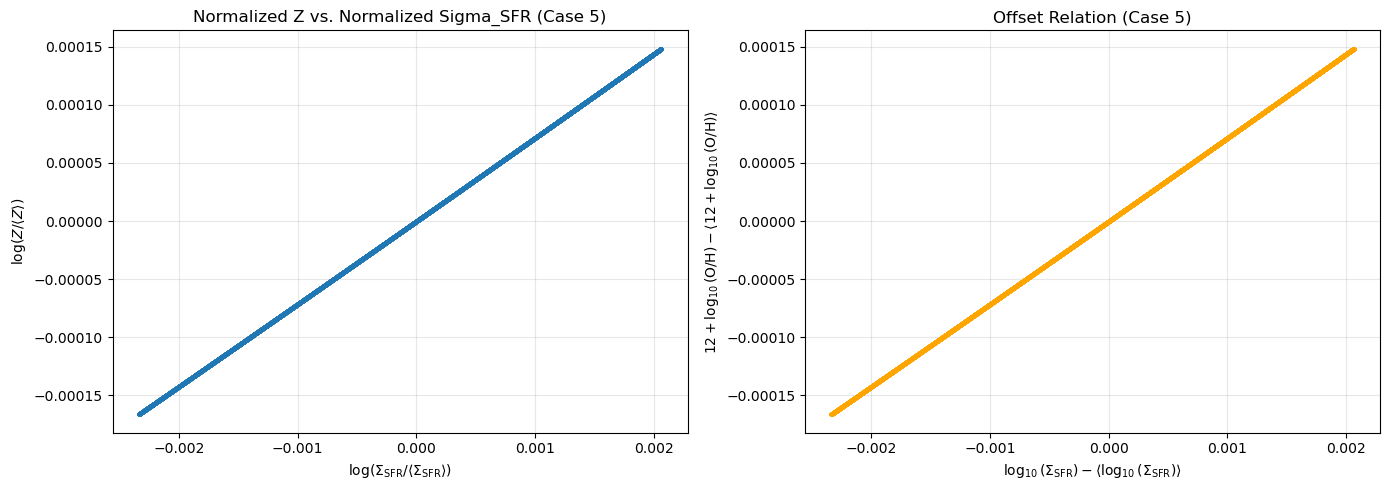

In [19]:
# Create boolean mask for stable region (0.4e10 yr to 0.6e10 yr)
mask_stable = (t_array_exp_epsilon_const_Sigma_in >= 0.4e10) * (t_array_exp_epsilon_const_Sigma_in <= 0.6e10)

# Calculate offsets
offset_OH = OH_array_exp_epsilon_const_Sigma_in[mask_stable] - np.mean(OH_array_exp_epsilon_const_Sigma_in[mask_stable])
offset_log10_Sigma_SFR = (np.log10(Sigma_SFR_array_exp_epsilon_const_Sigma_in[mask_stable]) - 
                           np.mean(np.log10(Sigma_SFR_array_exp_epsilon_const_Sigma_in[mask_stable])))

# Create figure with 2 subplots (1 row x 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: log(Z/<Z>) vs log(Sigma_SFR/<Sigma_SFR>)
axes[0].plot(
    np.log10(Sigma_SFR_array_exp_epsilon_const_Sigma_in[mask_stable] / 
             np.mean(Sigma_SFR_array_exp_epsilon_const_Sigma_in[mask_stable])),
    np.log10(Z_array_exp_epsilon_const_Sigma_in[mask_stable] / 
             np.mean(Z_array_exp_epsilon_const_Sigma_in[mask_stable])),
    'o', markersize=2, alpha=0.5
)
axes[0].set_xlabel(r'log($\Sigma_{\rm SFR} / \langle\Sigma_{\rm SFR}\rangle$)')
axes[0].set_ylabel(r'log($Z / \langle Z\rangle$)')
axes[0].set_title('Normalized Z vs. Normalized Sigma_SFR (Case 5)')
axes[0].grid(True, alpha=0.3)

# Right plot: offset vs offset
axes[1].plot(offset_log10_Sigma_SFR, offset_OH, 'o', markersize=2, alpha=0.5, color='orange')
axes[1].set_xlabel(r'$\log_{10}(\Sigma_{\rm SFR}) - \langle\log_{10}(\Sigma_{\rm SFR})\rangle$')
axes[1].set_ylabel(r'$12+\log_{10}({\rm O/H}) - \langle 12+\log_{10}({\rm O/H})\rangle$')
axes[1].set_title('Offset Relation (Case 5)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20251105 Case 6: exponential decay of $\Sigma_\mathrm{in}[t]$ and constant $\epsilon[t]$

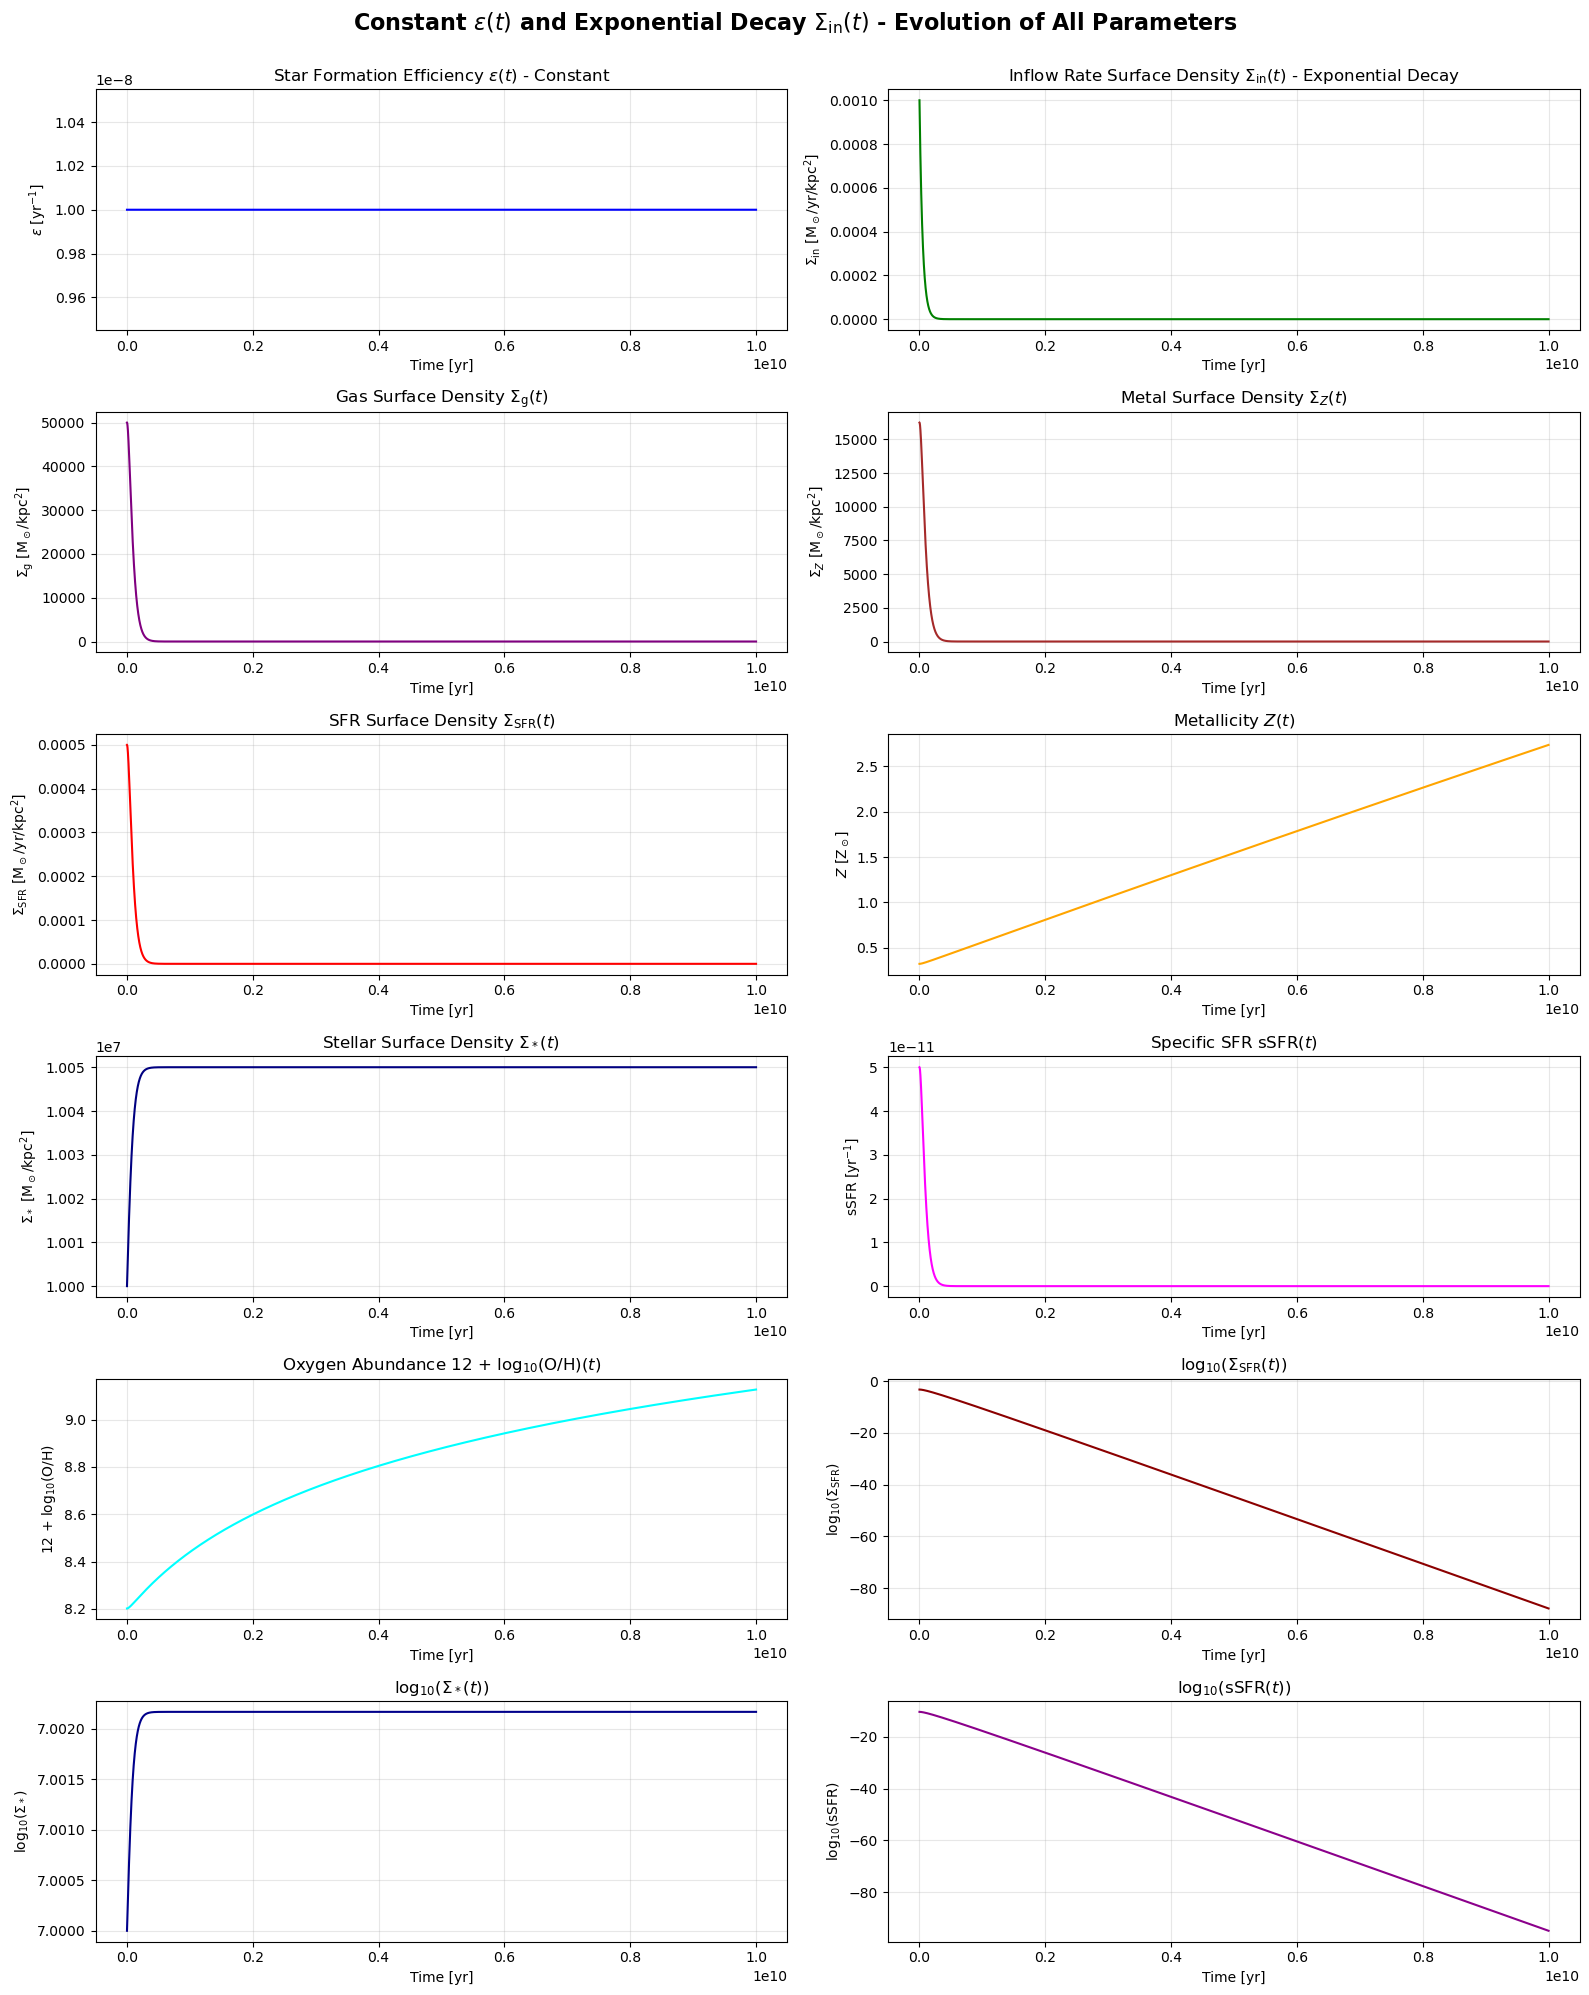


Summary of Case 6 evolution:
  Initial Z = 0.325000 Z_sol
  Final Z = 2.733156 Z_sol


In [20]:
## Visualization of all 12 parameters evolution for Case 6: constant epsilon and exponential decay Sigma_in

# Create figure with 12 subplots (6 rows x 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
axes = axes.flatten()

# 1. epsilon[t]
axes[0].plot(t_array_const_epsilon_exp_Sigma_in, epsilon_array_const_epsilon_exp_Sigma_in, 'b-', linewidth=1.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'$\epsilon$ [yr$^{-1}$]')
axes[0].set_title(r'Star Formation Efficiency $\epsilon(t)$ - Constant')
axes[0].grid(True, alpha=0.3)

# 2. Sigma_in[t]
axes[1].plot(t_array_const_epsilon_exp_Sigma_in, Sigma_in_array_const_epsilon_exp_Sigma_in, 'g-', linewidth=1.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'$\Sigma_{\rm in}$ [M$_\odot$/yr/kpc$^2$]')
axes[1].set_title(r'Inflow Rate Surface Density $\Sigma_{\rm in}(t)$ - Exponential Decay')
axes[1].grid(True, alpha=0.3)

# 3. Sigma_g[t]
axes[2].plot(t_array_const_epsilon_exp_Sigma_in, Sigma_g_array_const_epsilon_exp_Sigma_in, 'purple', linewidth=1.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'$\Sigma_{\rm g}$ [M$_\odot$/kpc$^2$]')
axes[2].set_title(r'Gas Surface Density $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. Sigma_Z[t]
axes[3].plot(t_array_const_epsilon_exp_Sigma_in, Sigma_Z_array_const_epsilon_exp_Sigma_in, 'brown', linewidth=1.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'$\Sigma_Z$ [M$_\odot$/kpc$^2$]')
axes[3].set_title(r'Metal Surface Density $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. Sigma_SFR[t]
axes[4].plot(t_array_const_epsilon_exp_Sigma_in, Sigma_SFR_array_const_epsilon_exp_Sigma_in, 'red', linewidth=1.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'$\Sigma_{\rm SFR}$ [M$_\odot$/yr/kpc$^2$]')
axes[4].set_title(r'SFR Surface Density $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. Z[t]
axes[5].plot(t_array_const_epsilon_exp_Sigma_in, Z_array_const_epsilon_exp_Sigma_in, 'orange', linewidth=1.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'$Z$ [Z$_\odot$]')
axes[5].set_title(r'Metallicity $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. Sigma_star[t]
axes[6].plot(t_array_const_epsilon_exp_Sigma_in, Sigma_star_array_const_epsilon_exp_Sigma_in, 'navy', linewidth=1.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'$\Sigma_*$ [M$_\odot$/kpc$^2$]')
axes[6].set_title(r'Stellar Surface Density $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. sSFR[t]
axes[7].plot(t_array_const_epsilon_exp_Sigma_in, sSFR_array_const_epsilon_exp_Sigma_in, 'magenta', linewidth=1.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'sSFR [yr$^{-1}$]')
axes[7].set_title(r'Specific SFR sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# 9. 12 + log10(O/H)[t]
axes[8].plot(t_array_const_epsilon_exp_Sigma_in, OH_array_const_epsilon_exp_Sigma_in, 'cyan', linewidth=1.5)
axes[8].set_xlabel('Time [yr]')
axes[8].set_ylabel(r'12 + log$_{10}$(O/H)')
axes[8].set_title(r'Oxygen Abundance 12 + log$_{10}$(O/H)$(t)$')
axes[8].grid(True, alpha=0.3)

# 10. log10(Sigma_SFR)[t]
axes[9].plot(t_array_const_epsilon_exp_Sigma_in, log10_Sigma_SFR_array_const_epsilon_exp_Sigma_in, 'darkred', linewidth=1.5)
axes[9].set_xlabel('Time [yr]')
axes[9].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$)')
axes[9].set_title(r'log$_{10}$($\Sigma_{\rm SFR}(t)$)')
axes[9].grid(True, alpha=0.3)

# 11. log10(Sigma_star)[t]
axes[10].plot(t_array_const_epsilon_exp_Sigma_in, log10_Sigma_star_array_const_epsilon_exp_Sigma_in, 'darkblue', linewidth=1.5)
axes[10].set_xlabel('Time [yr]')
axes[10].set_ylabel(r'log$_{10}$($\Sigma_*$)')
axes[10].set_title(r'log$_{10}$($\Sigma_*(t)$)')
axes[10].grid(True, alpha=0.3)

# 12. log10(sSFR)[t]
axes[11].plot(t_array_const_epsilon_exp_Sigma_in, log10_sSFR_array_const_epsilon_exp_Sigma_in, 'darkmagenta', linewidth=1.5)
axes[11].set_xlabel('Time [yr]')
axes[11].set_ylabel(r'log$_{10}$(sSFR)')
axes[11].set_title(r'log$_{10}$(sSFR$(t)$)')
axes[11].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Constant $\\epsilon(t)$ and Exponential Decay $\\Sigma_{\\rm in}(t)$ - Evolution of All Parameters', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nSummary of Case 6 evolution:")
print(f"  Initial Z = {Z_array_const_epsilon_exp_Sigma_in[0]:.6f} Z_sol")
print(f"  Final Z = {Z_array_const_epsilon_exp_Sigma_in[-1]:.6f} Z_sol")

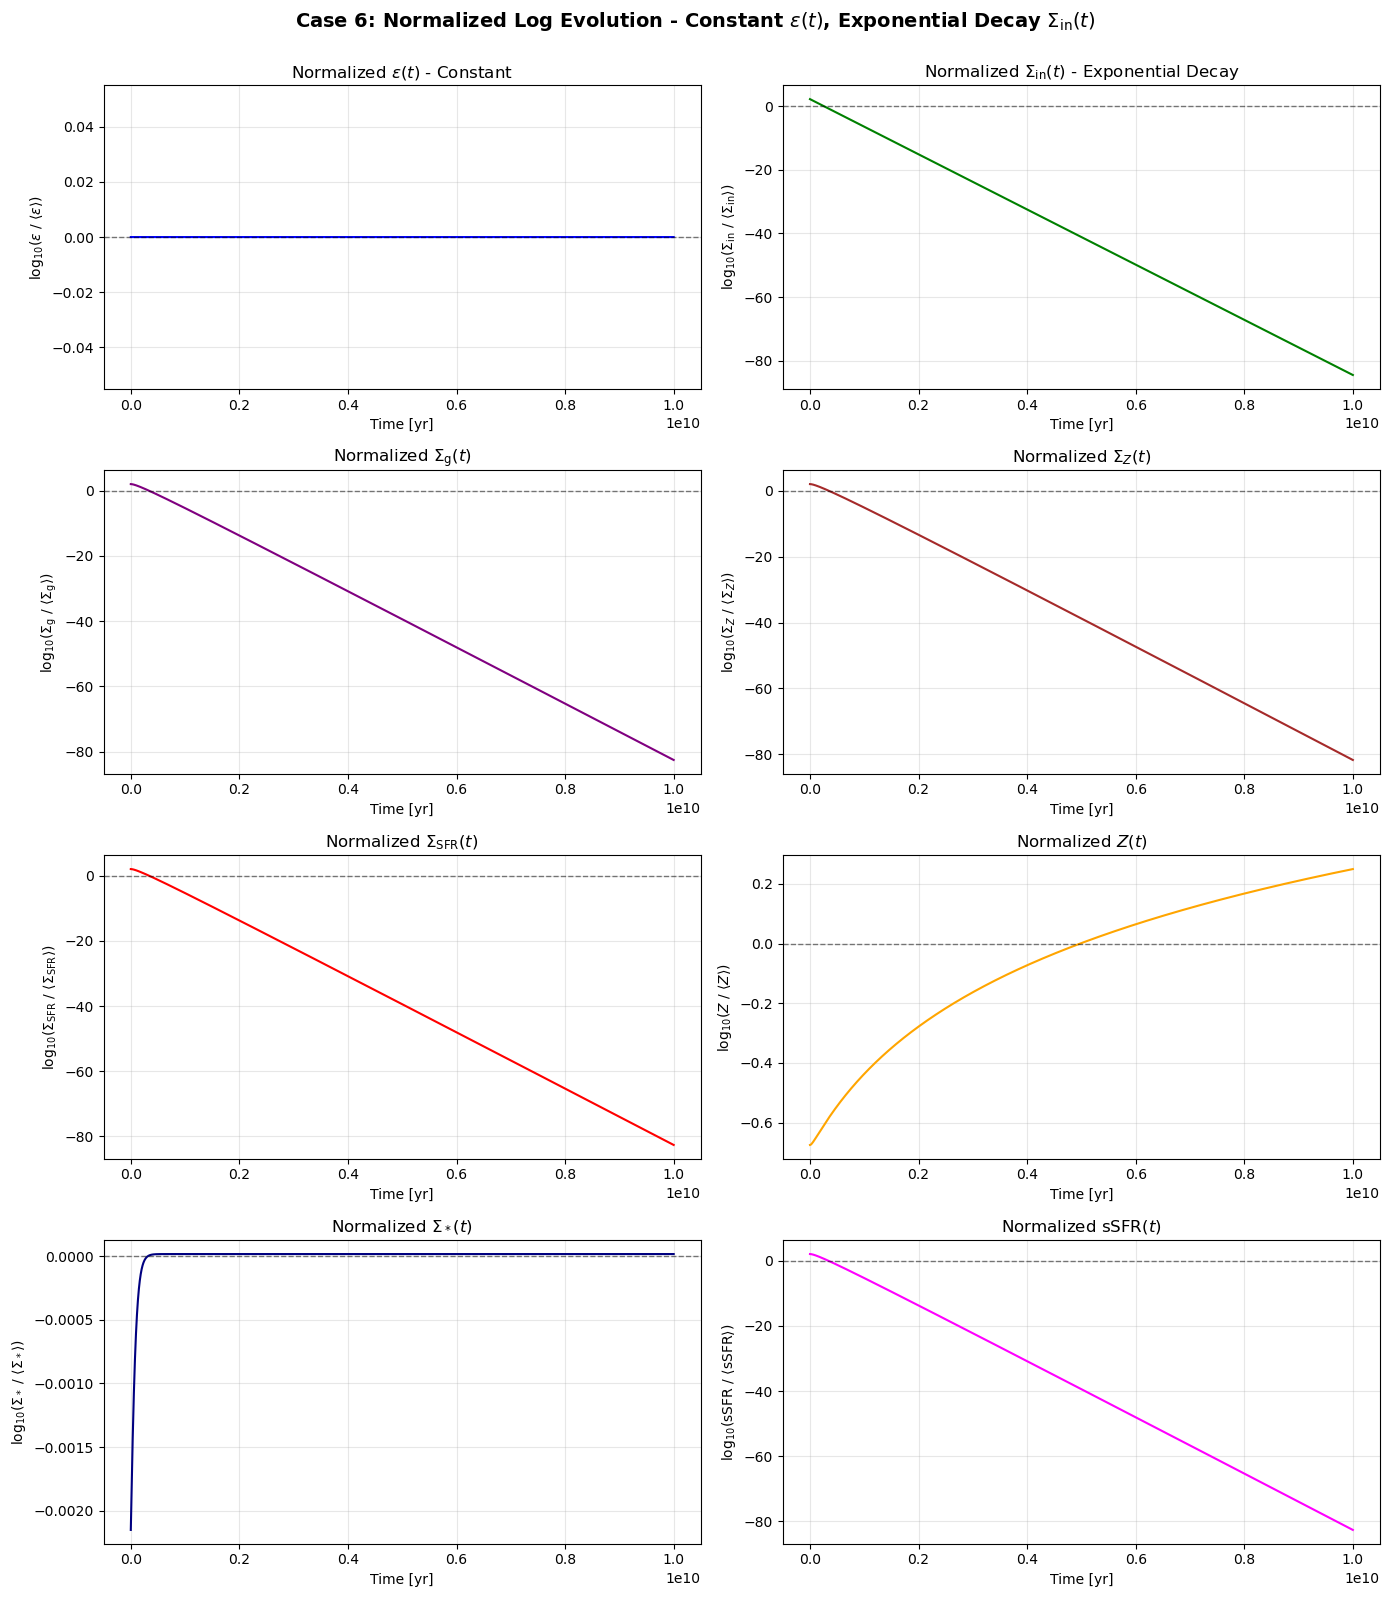


Mean values for Case 6:
  <epsilon> = 1.000000e-08 1/yr
  <Sigma_in> = 5.004952e-06 M_sol/yr/kpc^2
  <Sigma_g> = 5.002451e+02 M_sol/kpc^2
  <Sigma_Z> = 1.688296e+02 M_sol/kpc^2
  <Sigma_SFR> = 5.002451e-06 M_sol/yr/kpc^2
  <Z> = 1.537033 Z_sol
  <Sigma_star> = 1.004965e+07 M_sol/kpc^2
  <sSFR> = 4.989988e-13 1/yr


In [21]:
## Plot normalized evolution (property/mean) for Case 6: constant epsilon, exponential decay Sigma_in
## Using log scale: log10(quantity / <quantity>)

# Create figure with 8 subplots (4 rows x 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# 1. log10(epsilon / <epsilon>)
axes[0].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(epsilon_array_const_epsilon_exp_Sigma_in / np.mean(epsilon_array_const_epsilon_exp_Sigma_in)), 
             'b-', linewidth=1.5)
axes[0].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Time [yr]')
axes[0].set_ylabel(r'log$_{10}$($\epsilon$ / $\langle\epsilon\rangle$)')
axes[0].set_title(r'Normalized $\epsilon(t)$ - Constant')
axes[0].grid(True, alpha=0.3)

# 2. log10(Sigma_in / <Sigma_in>)
axes[1].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(Sigma_in_array_const_epsilon_exp_Sigma_in / np.mean(Sigma_in_array_const_epsilon_exp_Sigma_in)), 
             'g-', linewidth=1.5)
axes[1].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Time [yr]')
axes[1].set_ylabel(r'log$_{10}$($\Sigma_{\rm in}$ / $\langle\Sigma_{\rm in}\rangle$)')
axes[1].set_title(r'Normalized $\Sigma_{\rm in}(t)$ - Exponential Decay')
axes[1].grid(True, alpha=0.3)

# 3. log10(Sigma_g / <Sigma_g>)
axes[2].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(Sigma_g_array_const_epsilon_exp_Sigma_in / np.mean(Sigma_g_array_const_epsilon_exp_Sigma_in)), 
             'purple', linewidth=1.5)
axes[2].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel('Time [yr]')
axes[2].set_ylabel(r'log$_{10}$($\Sigma_{\rm g}$ / $\langle\Sigma_{\rm g}\rangle$)')
axes[2].set_title(r'Normalized $\Sigma_{\rm g}(t)$')
axes[2].grid(True, alpha=0.3)

# 4. log10(Sigma_Z / <Sigma_Z>)
axes[3].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(Sigma_Z_array_const_epsilon_exp_Sigma_in / np.mean(Sigma_Z_array_const_epsilon_exp_Sigma_in)), 
             'brown', linewidth=1.5)
axes[3].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[3].set_xlabel('Time [yr]')
axes[3].set_ylabel(r'log$_{10}$($\Sigma_Z$ / $\langle\Sigma_Z\rangle$)')
axes[3].set_title(r'Normalized $\Sigma_Z(t)$')
axes[3].grid(True, alpha=0.3)

# 5. log10(Sigma_SFR / <Sigma_SFR>)
axes[4].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(Sigma_SFR_array_const_epsilon_exp_Sigma_in / np.mean(Sigma_SFR_array_const_epsilon_exp_Sigma_in)), 
             'red', linewidth=1.5)
axes[4].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[4].set_xlabel('Time [yr]')
axes[4].set_ylabel(r'log$_{10}$($\Sigma_{\rm SFR}$ / $\langle\Sigma_{\rm SFR}\rangle$)')
axes[4].set_title(r'Normalized $\Sigma_{\rm SFR}(t)$')
axes[4].grid(True, alpha=0.3)

# 6. log10(Z / <Z>)
axes[5].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(Z_array_const_epsilon_exp_Sigma_in / np.mean(Z_array_const_epsilon_exp_Sigma_in)), 
             'orange', linewidth=1.5)
axes[5].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[5].set_xlabel('Time [yr]')
axes[5].set_ylabel(r'log$_{10}$($Z$ / $\langle Z\rangle$)')
axes[5].set_title(r'Normalized $Z(t)$')
axes[5].grid(True, alpha=0.3)

# 7. log10(Sigma_star / <Sigma_star>)
axes[6].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(Sigma_star_array_const_epsilon_exp_Sigma_in / np.mean(Sigma_star_array_const_epsilon_exp_Sigma_in)), 
             'navy', linewidth=1.5)
axes[6].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[6].set_xlabel('Time [yr]')
axes[6].set_ylabel(r'log$_{10}$($\Sigma_*$ / $\langle\Sigma_*\rangle$)')
axes[6].set_title(r'Normalized $\Sigma_*(t)$')
axes[6].grid(True, alpha=0.3)

# 8. log10(sSFR / <sSFR>)
axes[7].plot(t_array_const_epsilon_exp_Sigma_in, 
             np.log10(sSFR_array_const_epsilon_exp_Sigma_in / np.mean(sSFR_array_const_epsilon_exp_Sigma_in)), 
             'magenta', linewidth=1.5)
axes[7].axhline(y=0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[7].set_xlabel('Time [yr]')
axes[7].set_ylabel(r'log$_{10}$(sSFR / $\langle$sSFR$\rangle$)')
axes[7].set_title(r'Normalized sSFR$(t)$')
axes[7].grid(True, alpha=0.3)

# Add overall title
fig.suptitle('Case 6: Normalized Log Evolution - Constant $\\epsilon(t)$, Exponential Decay $\\Sigma_{\\rm in}(t)$', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

print(f"\nMean values for Case 6:")
print(f"  <epsilon> = {np.mean(epsilon_array_const_epsilon_exp_Sigma_in):.6e} 1/yr")
print(f"  <Sigma_in> = {np.mean(Sigma_in_array_const_epsilon_exp_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Sigma_g> = {np.mean(Sigma_g_array_const_epsilon_exp_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_Z> = {np.mean(Sigma_Z_array_const_epsilon_exp_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <Sigma_SFR> = {np.mean(Sigma_SFR_array_const_epsilon_exp_Sigma_in):.6e} M_sol/yr/kpc^2")
print(f"  <Z> = {np.mean(Z_array_const_epsilon_exp_Sigma_in):.6f} Z_sol")
print(f"  <Sigma_star> = {np.mean(Sigma_star_array_const_epsilon_exp_Sigma_in):.6e} M_sol/kpc^2")
print(f"  <sSFR> = {np.mean(sSFR_array_const_epsilon_exp_Sigma_in):.6e} 1/yr")

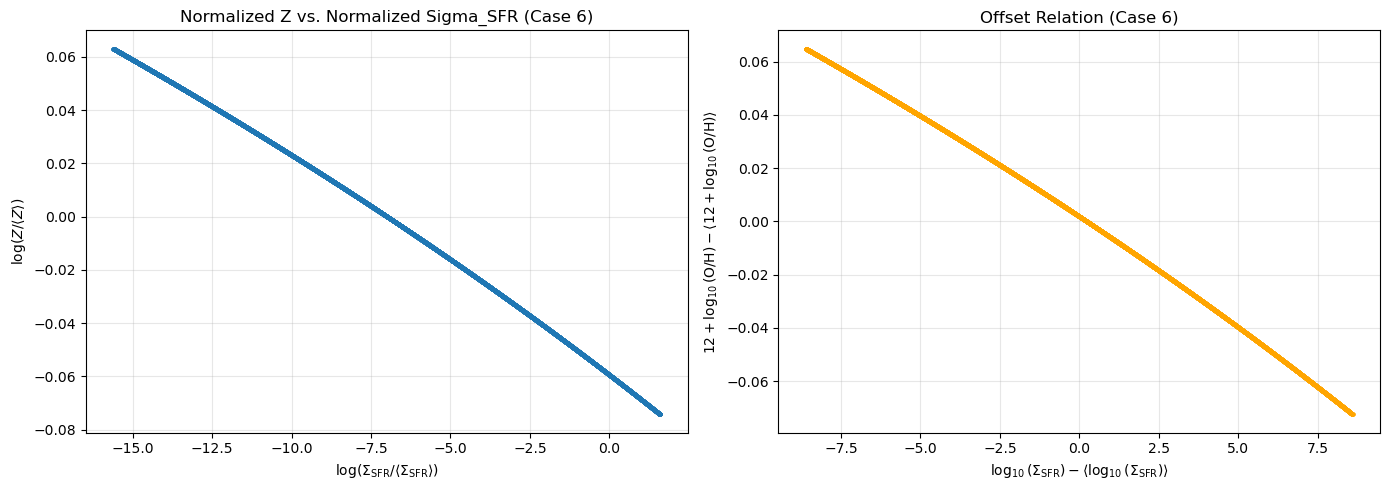

In [22]:
# Create boolean mask for stable region (0.4e10 yr to 0.6e10 yr)
mask_stable = (t_array_const_epsilon_exp_Sigma_in >= 0.4e10) * (t_array_const_epsilon_exp_Sigma_in <= 0.6e10)

# Calculate offsets
offset_OH = OH_array_const_epsilon_exp_Sigma_in[mask_stable] - np.mean(OH_array_const_epsilon_exp_Sigma_in[mask_stable])
offset_log10_Sigma_SFR = (np.log10(Sigma_SFR_array_const_epsilon_exp_Sigma_in[mask_stable]) - 
                           np.mean(np.log10(Sigma_SFR_array_const_epsilon_exp_Sigma_in[mask_stable])))

# Create figure with 2 subplots (1 row x 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: log(Z/<Z>) vs log(Sigma_SFR/<Sigma_SFR>)
axes[0].plot(
    np.log10(Sigma_SFR_array_const_epsilon_exp_Sigma_in[mask_stable] / 
             np.mean(Sigma_SFR_array_const_epsilon_exp_Sigma_in[mask_stable])),
    np.log10(Z_array_const_epsilon_exp_Sigma_in[mask_stable] / 
             np.mean(Z_array_const_epsilon_exp_Sigma_in[mask_stable])),
    'o', markersize=2, alpha=0.5
)
axes[0].set_xlabel(r'log($\Sigma_{\rm SFR} / \langle\Sigma_{\rm SFR}\rangle$)')
axes[0].set_ylabel(r'log($Z / \langle Z\rangle$)')
axes[0].set_title('Normalized Z vs. Normalized Sigma_SFR (Case 6)')
axes[0].grid(True, alpha=0.3)

# Right plot: offset vs offset
axes[1].plot(offset_log10_Sigma_SFR, offset_OH, 'o', markersize=2, alpha=0.5, color='orange')
axes[1].set_xlabel(r'$\log_{10}(\Sigma_{\rm SFR}) - \langle\log_{10}(\Sigma_{\rm SFR})\rangle$')
axes[1].set_ylabel(r'$12+\log_{10}({\rm O/H}) - \langle 12+\log_{10}({\rm O/H})\rangle$')
axes[1].set_title('Offset Relation (Case 6)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()